# Análisis Exploratorio de Datos (EDA)
## Base de Trabajo de Grado — Empleados Colombia (Permanentes)

Este notebook realiza un análisis exploratorio exhaustivo sobre la base de datos de empleados. El objetivo es comprender la estructura, distribución, calidad y relaciones entre las variables del dataset, con foco en la rotación de personal.

**Secciones:**
1. Carga de datos y librerías
2. Inspección general del dataset
3. Análisis de calidad de datos (nulos, duplicados, tipos)
4. Abálisis Variable por Variable
5. Limpieza de Variables

---
## 1. Carga de datos y librerías

In [492]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [493]:
import os

while os.path.basename(os.getcwd()) != "tesis_maestria":
    os.chdir("..")
 
os.getcwd()

'c:\\Users\\karen\\OneDrive\\Documentos\\maestria\\tesis_maestria'

In [494]:
import sys
print(sys.executable)
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install openpyxl

c:\Users\karen\AppData\Local\Programs\Python\Python310\python.exe


In [495]:
df = pd.read_excel("data/Base_Trabajo_Grado_fin.xlsx")
print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(10)

Dataset cargado: 5792 filas × 40 columnas


,Employee Code,Termination Code,Hours/ Week,Currency Code,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Job Level,Location Description,Type Location,Contract Type,Exchange Rate,Type,Termination Reason,Termination Type,Target Bonus %,Non Exempt,Active Employee,Hire Date,Termination Date,Target Equity %,Standardized_Salary,Active Supervisor,Supervisor Code,Gropued Supervisor Department,Supervisor Job ID,Probation Period Completed,Position vs Estimated Median,AGE,CPI,Cantidad Salarios Minimos
0,EMP_00001,J,48,COP,3,3,3,4,4,4,N,Cargo 1,Male,Common Law,CLUB OPERATIONS,Merchandising & Inventory,7,Pacífico I,Club,Full Time,3001.5000,C,Violation of Policy (Involun),Involuntary,0.0000,Non Exempt,N,2011-06-20,2013-09-27 00:00:00,0.0000,0.1996,N,Inactive,Inactive,Cargo 342,Yes,0.9124,33.0000,0.0194,66
1,EMP_00002,NaN,44,COP,0,0,0,4,4,4,N,Cargo 2,Male,Married,CLUB OPERATIONS,Fresh & Food Operations,5,Caribe I,Club,Full Time,3765.9200,C,NaN,Unknown,0.0000,Non Exempt,Y,2011-07-15,00:00:00,0.0000,0.1203,Y,EMP_01989,Fresh & Food Operations,Cargo 37,Yes,0.8280,38.0000,0.0510,24
2,EMP_00003,J,48,COP,0,0,0,4,4,4,N,Cargo 3,Male,Common Law,CLUB OPERATIONS,Member-Facing Operations,7,Pacífico I,Club,Full Time,3001.5000,C,Violation of Policy (Involun),Involuntary,0.0000,Non Exempt,N,2011-07-11,2014-08-27 00:00:00,0.0000,0.2267,N,Inactive,Inactive,Cargo 342,Yes,0.9124,29.0000,0.0366,65
3,EMP_00004,I,48,COP,2,2,2,4,4,4,N,Cargo 4,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,Pacífico I,Club,Full Time,3001.5000,C,Insubordination (Involuntary),Involuntary,0.0000,Non Exempt,N,2012-05-28,2013-04-15 00:00:00,0.0000,-0.2825,N,Inactive,Inactive,Cargo 342,Yes,0.8280,27.0000,0.0194,30
4,EMP_00005,E,48,COP,0,0,0,4,4,4,N,Cargo 5,Female,Married,CLUB OPERATIONS,Finance & Administrative Support,5,Pacífico I,Club,Full Time,3698.6000,C,Personal** DO NOT USE** (Vol),Voluntary,0.0000,Non Exempt,N,2012-05-30,2015-07-09 00:00:00,0.0000,-0.1472,N,Inactive,Inactive,Cargo 342,Yes,1.0277,33.0000,0.0677,37
5,EMP_00006,E,48,COP,0,0,0,4,4,4,N,Cargo 6,Male,Single,CLUB OPERATIONS,Member-Facing Operations,2,Pacífico I,Club,Full Time,3001.5000,C,Personal** DO NOT USE** (Vol),Voluntary,0.0000,Non Exempt,N,2012-06-11,2014-10-15 00:00:00,0.0000,-0.4561,N,Inactive,Inactive,Cargo 342,Yes,0.9596,32.0000,0.0366,17
6,EMP_00007,I,48,COP,0,0,0,4,4,4,N,Cargo 6,Female,Married,CLUB OPERATIONS,Member-Facing Operations,2,Pacífico I,Club,Full Time,3001.5000,C,Insubordination (Involuntary),Involuntary,0.0000,Non Exempt,N,2012-06-11,2014-02-18 00:00:00,0.0000,-0.4561,N,Inactive,Inactive,Cargo 342,Yes,0.9596,23.0000,0.0366,17
7,EMP_00008,I,48,COP,2,2,2,4,4,4,N,Cargo 7,Male,Single,CLUB OPERATIONS,Member-Facing Operations,4,Pacífico I,Club,Full Time,3001.5000,C,Insubordination (Involuntary),Involuntary,0.0000,Exempt,N,2012-06-11,2013-06-01 00:00:00,0.0000,-0.3729,N,Inactive,Inactive,Cargo 342,Yes,0.8280,22.0000,0.0194,24
8,EMP_00009,J,48,COP,1,1,1,4,4,4,N,Cargo 7,Female,Married,CLUB OPERATIONS,Member-Facing Operations,4,Pacífico I,Club,Full Time,3001.5000,C,Violation of Policy (Involun),Involuntary,0.0000,Non Exempt,N,2012-06-11,2013-07-22 00:00:00,0.0000,-0.3729,N,Inactive,Inactive,Cargo 342,Yes,0.8280,35.0000,0.0194,24
9,EMP_00010,NaN,44,COP,1,0,0,4,4,4,N,Cargo 8,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,Pacífico I,Club,Full Time,3765.9200,C,NaN,Unknown,0.0000,Non Exempt,Y,2012-06-11,00:00:00,0.0000,0.1203,Y,EMP_00185,Leadership,Cargo 13,Yes,0.8280,47.0000,0.0510,24


---
## 2. Inspección general del dataset

In [496]:
print('='*60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('='*60)
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print('Columnas y tipos de datos:')
print('-'*60)
df.info()

INFORMACIÓN GENERAL DEL DATASET
Filas: 5792
Columnas: 40
Columnas y tipos de datos:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Employee Code                  5792 non-null   object        
 1   Termination Code               3897 non-null   object        
 2   Hours/ Week                    5792 non-null   int64         
 3   Currency Code                  5792 non-null   object        
 4   English Reading Lvl            5792 non-null   int64         
 5   English Spoken Lvl             5792 non-null   int64         
 6   English Writing Lvl            5792 non-null   int64         
 7   Spanish Reading Lvl            5792 non-null   int64         
 8   Spanish Spoken Lvl             5792 non-null   int64         
 9   Spanis

In [497]:
# Ver todas las columnas actuales
print(df.columns.tolist())

['Employee Code', 'Termination Code', 'Hours/ Week', 'Currency Code', 'English Reading Lvl', 'English Spoken Lvl', 'English Writing Lvl', 'Spanish Reading Lvl', 'Spanish Spoken Lvl', 'Spanish Writing Lvl', 'Union', 'Employee Job ID', 'Gender', 'Marital Status', 'Area', 'Grouped Department Name', 'Job Level', 'Location Description', 'Type Location', 'Contract Type', 'Exchange Rate', 'Type', 'Termination Reason', 'Termination Type', 'Target Bonus %', 'Non Exempt', 'Active Employee', 'Hire Date', 'Termination Date', 'Target Equity %', 'Standardized_Salary', 'Active Supervisor', 'Supervisor Code', 'Gropued Supervisor Department', 'Supervisor Job ID', 'Probation Period Completed', 'Position vs Estimated Median', 'AGE', 'CPI', 'Cantidad Salarios Minimos']


In [498]:
print('Estadísticas descriptivas — Variables numéricas:')
df.describe()

Estadísticas descriptivas — Variables numéricas:


,Hours/ Week,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Job Level,Exchange Rate,Target Bonus %,Hire Date,Target Equity %,Standardized_Salary,Position vs Estimated Median,AGE,CPI,Cantidad Salarios Minimos
count,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792,5792.0000,5792.0000,5792.0000,5791.0000,5792.0000,5792.0000
mean,45.7536,0.6221,0.6117,0.6269,3.0570,3.0566,3.0471,3.1039,3695.4444,0.0043,2019-07-31 18:51:27.845304064,0.0017,-0.0000,0.9240,31.4763,0.0580,26.5547
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2705.7500,0.0000,1998-11-02 00:00:00,0.0000,-0.5753,0.3440,0.0000,0.0161,6.0000
25%,44.0000,0.0000,0.0000,0.0000,4.0000,4.0000,4.0000,2.0000,3421.0550,0.0000,2016-03-17 18:00:00,0.0000,-0.3630,0.8565,26.0000,0.0510,16.0000
50%,48.0000,0.0000,0.0000,0.0000,4.0000,4.0000,4.0000,2.0000,3765.9200,0.0000,2020-03-02 00:00:00,0.0000,-0.2107,0.9166,30.0000,0.0510,18.0000
75%,48.0000,1.0000,1.0000,1.0000,4.0000,4.0000,4.0000,4.0000,3909.5125,0.0000,2023-01-23 00:00:00,0.0000,-0.0552,0.9596,36.0000,0.0575,24.0000
max,48.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,16.0000,5104.0000,0.3000,2025-12-19 00:00:00,0.4000,20.7953,2.2755,67.0000,0.1312,1212.0000
std,4.3370,1.2394,1.2289,1.2477,1.6872,1.6875,1.6919,1.9805,457.4823,0.0271,NaN,0.0159,1.0000,0.1345,7.4749,0.0269,39.0397


In [499]:
print('Estadísticas descriptivas — Variables categóricas:')
df.describe(include='object')

Estadísticas descriptivas — Variables categóricas:


,Employee Code,Termination Code,Currency Code,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Location Description,Type Location,Contract Type,Type,Termination Reason,Termination Type,Non Exempt,Active Employee,Termination Date,Active Supervisor,Supervisor Code,Gropued Supervisor Department,Supervisor Job ID,Probation Period Completed
count,5792,3897,5792,5036,5792,5792,5791,5792,5792,5792,5792,5792,5792,3897,5792,5792,5792,5792,5792,5792,5792,5792,5792
unique,5792,34,2,3,341,3,8,12,13,14,4,2,4,34,3,2,2,2123,2,354,15,130,2
top,EMP_00001,B,COP,N,Cargo 31,Male,Single,CLUB OPERATIONS,Member-Facing Operations,Centro Occidente I,Club,Full Time,C,Better Job Opp (Voluntary),Voluntary,Non Exempt,N,00:00:00,Y,Inactive,Inactive,Cargo 342,Yes
freq,1,663,5780,5030,621,3482,3510,5067,1620,814,5003,5590,5003,663,2021,2905,3897,1895,3924,1868,1868,1868,5743


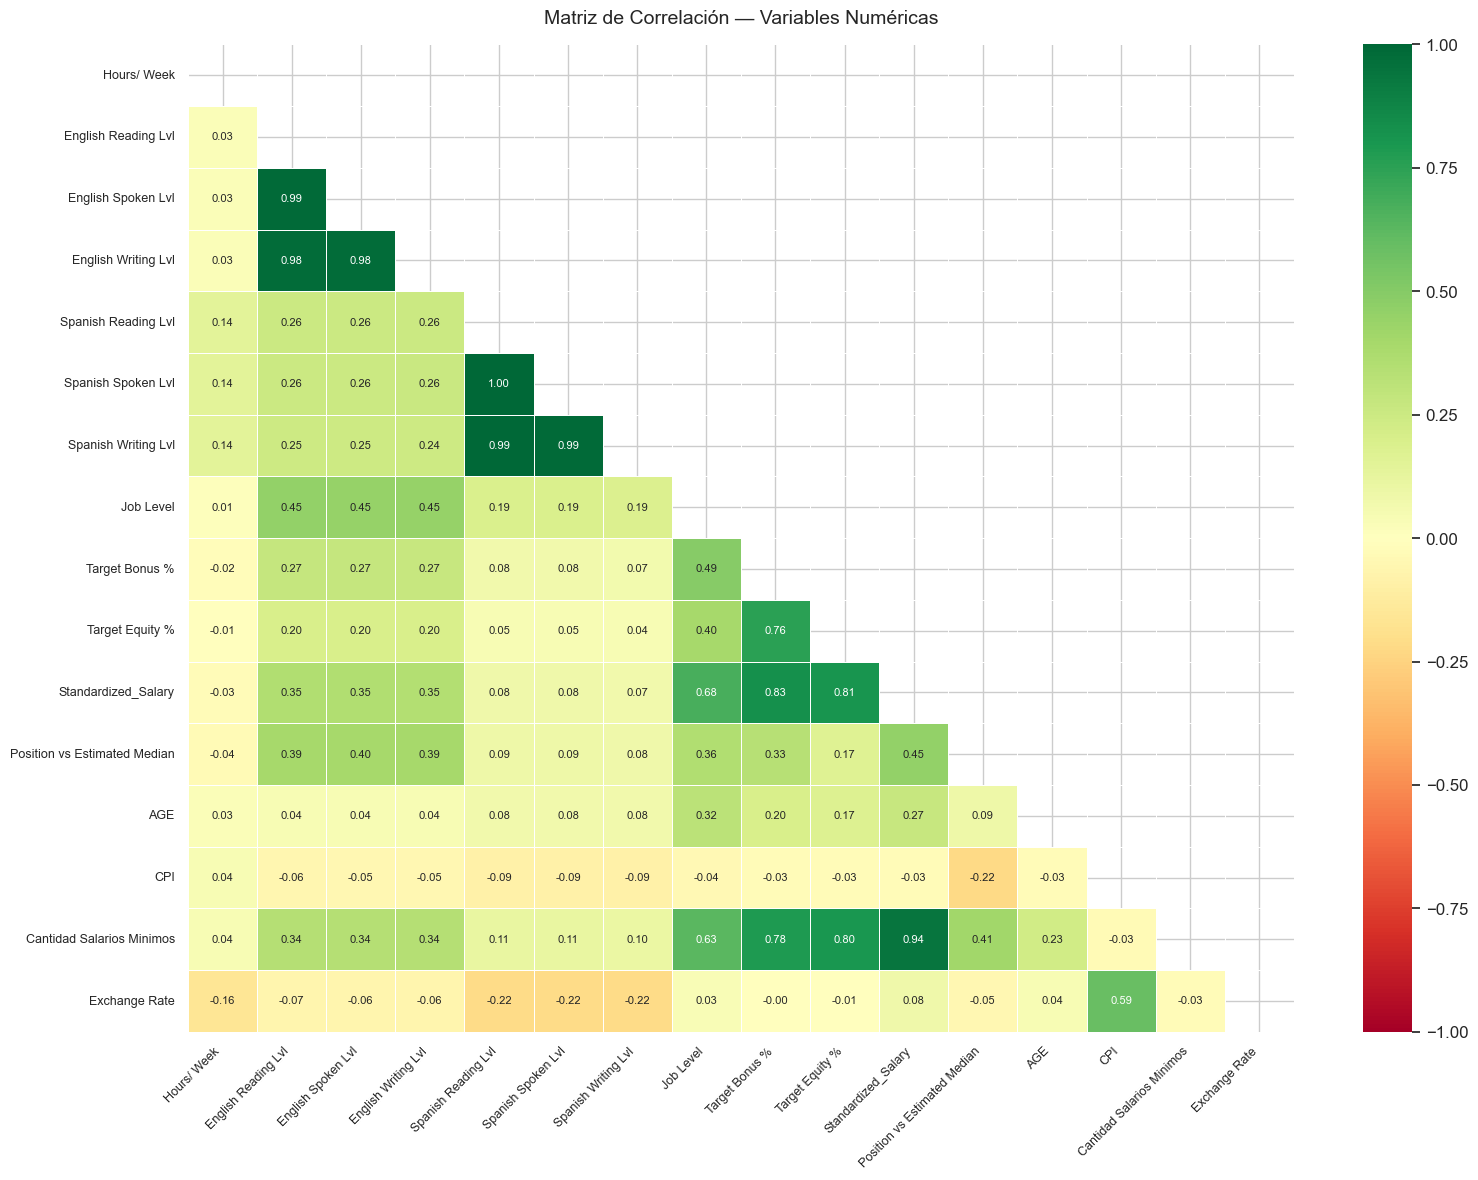

Pares con correlación alta (|r| >= 0.70):
               Variable 1          Variable 2  Correlación
       Spanish Spoken Lvl Spanish Reading Lvl       0.9977
      Spanish Writing Lvl Spanish Reading Lvl       0.9926
      Spanish Writing Lvl  Spanish Spoken Lvl       0.9921
       English Spoken Lvl English Reading Lvl       0.9887
      English Writing Lvl  English Spoken Lvl       0.9831
      English Writing Lvl English Reading Lvl       0.9804
Cantidad Salarios Minimos Standardized_Salary       0.9385
      Standardized_Salary      Target Bonus %       0.8337
      Standardized_Salary     Target Equity %       0.8099
Cantidad Salarios Minimos     Target Equity %       0.8044
Cantidad Salarios Minimos      Target Bonus %       0.7841
          Target Equity %      Target Bonus %       0.7568


In [500]:
# Variables numéricas a incluir en la correlación
num_cols = [
    'Hours/ Week',
    'English Reading Lvl', 'English Spoken Lvl', 'English Writing Lvl',
    'Spanish Reading Lvl', 'Spanish Spoken Lvl', 'Spanish Writing Lvl',
    'Job Level', 'Target Bonus %', 'Target Equity %',
    'Standardized_Salary', 'Position vs Estimated Median',
    'AGE', 'CPI', 'Cantidad Salarios Minimos', 'Exchange Rate'
]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Tabla de pares con alta correlación (|r| >= 0.7) para documentar
print("Pares con correlación alta (|r| >= 0.70):")
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlación']
high_corr = corr_pairs[corr_pairs['Correlación'].abs() >= 0.70].sort_values('Correlación', ascending=False)
print(high_corr.to_string(index=False))

---
## 3. Análisis de calidad de datos

Columnas sin nulos: 35 / 40
Columnas con al menos 1 nulo: 5 / 40

--- Detalle de columnas con nulos ---


,Nulos,Porcentaje (%),Tipo
Termination Code,1895,32.7200,object
Termination Reason,1895,32.7200,object
Union,756,13.0500,object
AGE,1,0.0200,float64
Marital Status,1,0.0200,object


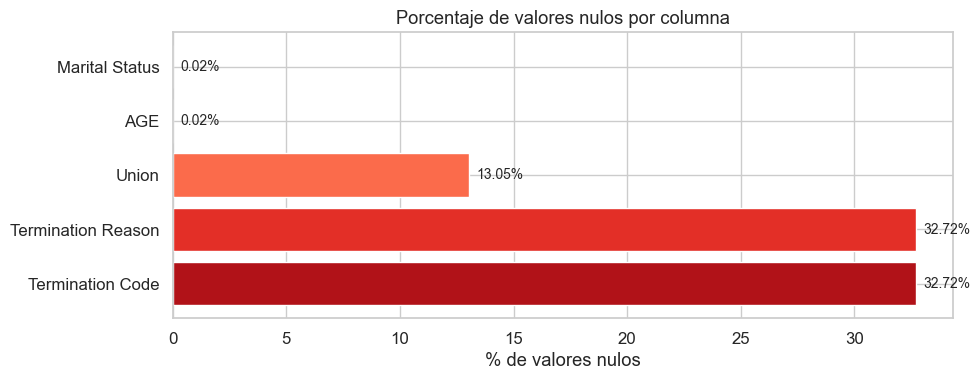

In [501]:
# --- Valores nulos ---
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Nulos': nulls,
    'Porcentaje (%)': nulls_pct,
    'Tipo': df.dtypes.astype(str)
}).sort_values('Porcentaje (%)', ascending=False)

print(f'Columnas sin nulos: {(nulls == 0).sum()} / {len(nulls)}')
print(f'Columnas con al menos 1 nulo: {(nulls > 0).sum()} / {len(nulls)}')
print()
print('--- Detalle de columnas con nulos ---')
display(null_df[null_df['Nulos'] > 0])

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
cols_con_nulos = null_df[null_df['Nulos'] > 0]
bars = ax.barh(cols_con_nulos.index, cols_con_nulos['Porcentaje (%)'], color=sns.color_palette('Reds_r', len(cols_con_nulos)))
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de valores nulos por columna')
for bar, val in zip(bars, cols_con_nulos['Porcentaje (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [502]:
# --- Duplicados ---
dupes_total = df.duplicated().sum()
dupes_emp   = df.duplicated(subset='Employee Code').sum()

print(f'Filas duplicadas (todas las columnas): {dupes_total}')
print(f'Employee Codes duplicados:             {dupes_emp}')
print(f'Employee Codes únicos:                 {df["Employee Code"].nunique():,} / {len(df):,}')

Filas duplicadas (todas las columnas): 0
Employee Codes duplicados:             0
Employee Codes únicos:                 5,792 / 5,792


In [503]:
# Únicos de cada columna
cardinality = pd.DataFrame({
    'Valores únicos': df.nunique(),
    '% únicos': (df.nunique() / len(df) * 100).round(2),
    'Tipo': df.dtypes,
    'Muestra': [str(df[c].dropna().unique()[:5].tolist()) for c in df.columns]
}).sort_values('Valores únicos', ascending=False)

print('CANTIDAD VALORES ÚNICOS POR COLUMNA')
print('='*60)
cardinality

CANTIDAD VALORES ÚNICOS POR COLUMNA


,Valores únicos,% únicos,Tipo,Muestra
Employee Code,5792,100.0000,object,"['EMP_00001', 'EMP_00002', 'EMP_00003', 'EMP_0..."
Termination Date,2123,36.6500,object,"[datetime.datetime(2013, 9, 27, 0, 0), datetim..."
Hire Date,1634,28.2100,datetime64[ns],"[Timestamp('2011-06-20 00:00:00'), Timestamp('..."
Exchange Rate,1484,25.6200,float64,"[3001.5, 3765.92, 3698.6, 2987.57, 3088.44]"
Standardized_Salary,842,14.5400,float64,"[0.1996017650088621, 0.12028951686917123, 0.22..."
Position vs Estimated Median,706,12.1900,float64,"[0.9123698041863606, 0.828, 0.9123694800810264..."
Supervisor Code,354,6.1100,object,"['Inactive', 'EMP_01989', 'EMP_00185', 'EMP_00..."
Employee Job ID,341,5.8900,object,"['Cargo 1', 'Cargo 2', 'Cargo 3', 'Cargo 4', '..."
Cantidad Salarios Minimos,147,2.5400,int64,"[66, 24, 65, 30, 37]"
Supervisor Job ID,130,2.2400,object,"['Cargo 342', 'Cargo 37', 'Cargo 13', 'Cargo 9..."


---
## 4. Análisis variable por variable (las 40 columnas)

Se documenta cada variable: tipo, distribución, observaciones y relevancia para el modelo.

Variable 1: Employee Code: No aporta valor predictivo — es una llave primaria. Podría usarse para calcular el número de jefes distintos, pero no como feature directa.

Variable 2: Termination Code: 
→ Altamente correlacionado con Termination Reason. Puede descartarse si se usa Termination Reason.
→ NaN indica empleado activo (dato implícito, no faltante real).

VARIABLE 3 — Hours/Week
             count
Hours/ Week       
48            2932
44            2018
46             356
47             333
24             110
23              22
22              10
0                8
36               1
8                1
40               1

  Media: 45.8 | Mín: 0 | Máx: 48


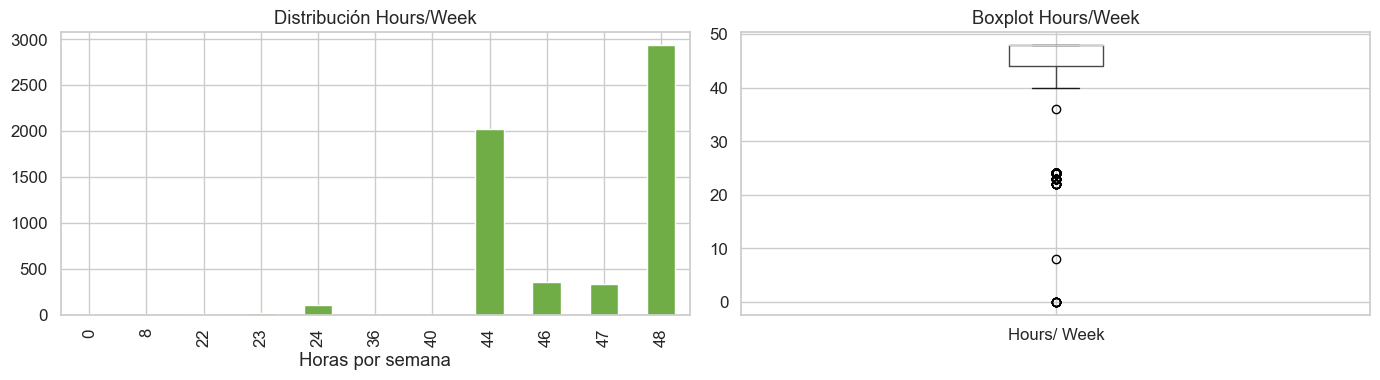

In [504]:
# ── Variable 3: Hours/Week ─────────────────────────────────────────────────
print('VARIABLE 3 — Hours/Week')
print(df['Hours/ Week'].value_counts().to_frame('count'))
print()
print(f'  Media: {df["Hours/ Week"].mean():.1f} | Mín: {df["Hours/ Week"].min()} | Máx: {df["Hours/ Week"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Hours/ Week'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#70ad47')
axes[0].set_title('Distribución Hours/Week')
axes[0].set_xlabel('Horas por semana')
df.boxplot(column='Hours/ Week', ax=axes[1])
axes[1].set_title('Boxplot Hours/Week')
plt.tight_layout()
plt.show()

Variable 3: Los que tienen horas en 0, son errores en datos, se debe revisar que acción se va a tomar, los del rango inferior a 44, se debe revisar que sean personas part time, de lo contrario, tambien seria error en el registro y debe tratarse

Variable 4: Currency Code: Desde la abse se dejaron todos los registros en moneda local COP, por lo que hay un error en las monedas que parecen como USD, seria una variable a eliminar porque seria única, no aporta valor, es la misma para todos

VARIABLES 5, 6, 7 — Niveles de Inglés (Reading, Spoken, Writing)
       English Reading Lvl  English Spoken Lvl  English Writing Lvl
count            5792.0000           5792.0000            5792.0000
mean                0.6221              0.6117               0.6269
std                 1.2394              1.2289               1.2477
min                 0.0000              0.0000               0.0000
25%                 0.0000              0.0000               0.0000
50%                 0.0000              0.0000               0.0000
75%                 1.0000              1.0000               1.0000
max                 4.0000              4.0000               4.0000


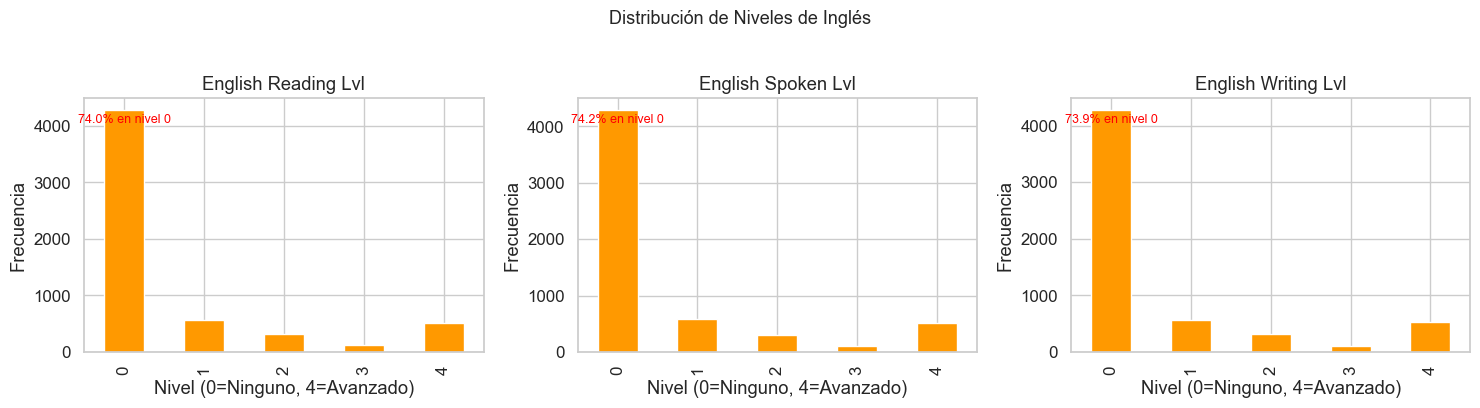

In [505]:
# ── Variables 5-7: Niveles de inglés ──────────────────────────────────────
english_cols = ['English Reading Lvl', 'English Spoken Lvl', 'English Writing Lvl']

print('VARIABLES 5, 6, 7 — Niveles de Inglés (Reading, Spoken, Writing)')
print(df[english_cols].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, english_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#ff9900')
    ax.set_title(col)
    ax.set_xlabel('Nivel (0=Ninguno, 4=Avanzado)')
    pct_cero = (df[col] == 0).mean() * 100
    ax.set_ylabel('Frecuencia')
    ax.annotate(f'{pct_cero:.1f}% en nivel 0', xy=(0, ax.get_ylim()[1]*0.9), ha='center', fontsize=9, color='red')
plt.suptitle('Distribución de Niveles de Inglés', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Variables 5-7: Niveles de inglés
→ Alta correlación entre las 3 variables → considerar crear un índice compuesto: english_score.
→ Mayoría en nivel 0 (empresa hispanohablante) → baja varianza predictiva por sí solas.

VARIABLES 8, 9, 10 — Niveles de Español (Reading, Spoken, Writing)
       Spanish Reading Lvl  Spanish Spoken Lvl  Spanish Writing Lvl
count            5792.0000           5792.0000            5792.0000
mean                3.0570              3.0566               3.0471
std                 1.6872              1.6875               1.6919
min                 0.0000              0.0000               0.0000
25%                 4.0000              4.0000               4.0000
50%                 4.0000              4.0000               4.0000
75%                 4.0000              4.0000               4.0000
max                 4.0000              4.0000               4.0000


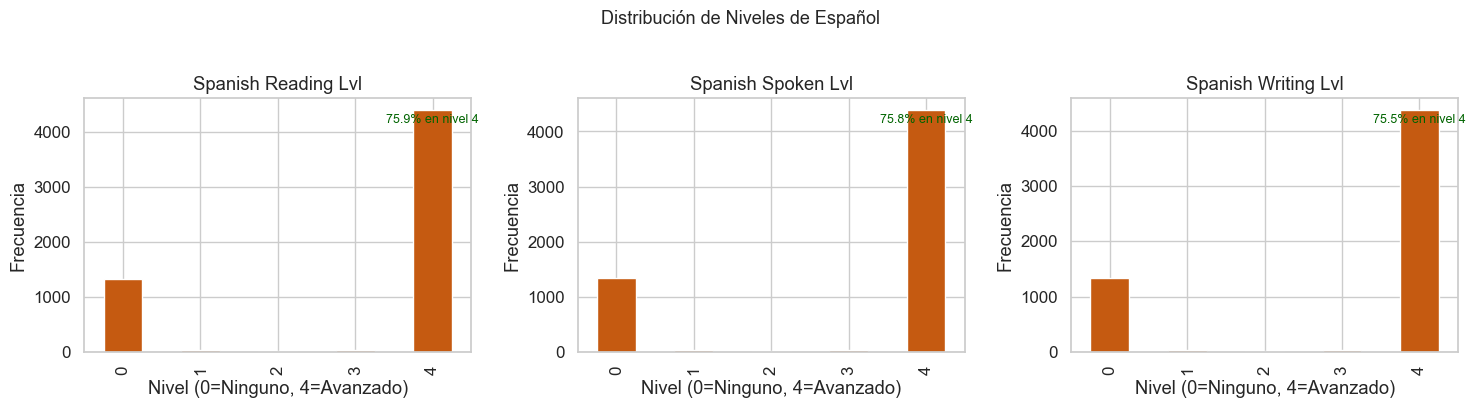

In [506]:
# ── Variables 8-10: Niveles de español ────────────────────────────────────
spanish_cols = ['Spanish Reading Lvl', 'Spanish Spoken Lvl', 'Spanish Writing Lvl']

print('VARIABLES 8, 9, 10 — Niveles de Español (Reading, Spoken, Writing)')
print(df[spanish_cols].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, spanish_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#c55a11')
    ax.set_title(col)
    ax.set_xlabel('Nivel (0=Ninguno, 4=Avanzado)')
    pct_cuatro = (df[col] == 4).mean() * 100
    ax.set_ylabel('Frecuencia')
    ax.annotate(f'{pct_cuatro:.1f}% en nivel 4', xy=(4, ax.get_ylim()[1]*0.9), ha='center', fontsize=9, color='darkgreen')
plt.suptitle('Distribución de Niveles de Español', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Variables 8-10: Niveles de español

→ Altísima correlación inter-variable → crear índice compuesto: spanish_score.
→ Mayoría en nivel 4 (empresa en Colombia) → baja varianza individual, creo que no aporta mucho valor al modelo, entonces podriamos quitarlo, hay gente que no tiene buen nivel de español, porque son personas de otras nacionalidades, pero en su mayoria se trata de personas que dominan el idioma, creo que puede ser más interesante el dominar el inglés que el español

In [507]:
# ── Variable 11: Union ────────────────────────────────────────────────────
print('VARIABLE 11 — Union')
print(df['Union'].value_counts(dropna=False))
print()


VARIABLE 11 — Union
Union
N      5030
NaN     756
Y         5
X         1
Name: count, dtype: int64



Variable 11: Union 
"N": significa que no están en el sindicanto y representa el 99.9% de los registros con valor.
Nulos: 756 (13.1%)
Varianza extremadamente baja (casi todos "N") → candidata a eliminación.

VARIABLE 12 — Employee Job ID
  Únicos: 341
  Top 10:
Employee Job ID
Cargo 31    621
Cargo 39    462
Cargo 17    440
Cargo 29    201
Cargo 36    180
Cargo 6     174
Cargo 43    148
Cargo 38    137
Cargo 15    128
Cargo 64    121
Name: count, dtype: int64


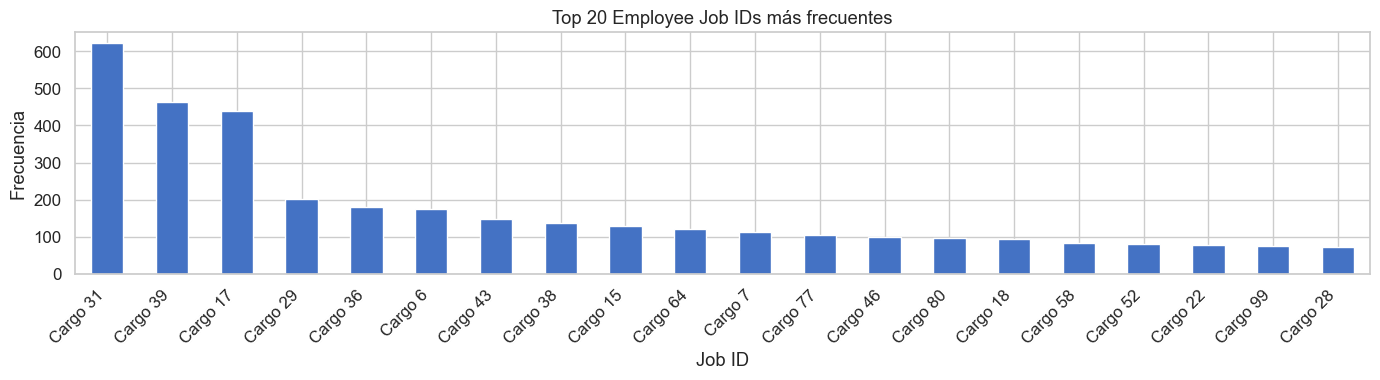

In [508]:
# ── Variable 12: Employee Job ID ──────────────────────────────────────────
print('VARIABLE 12 — Employee Job ID')
print(f'  Únicos: {df["Employee Job ID"].nunique()}')
print(f'  Top 10:')
print(df['Employee Job ID'].value_counts().head(10))

fig, ax = plt.subplots(figsize=(14, 4))
top_jobs = df['Employee Job ID'].value_counts().head(20)
top_jobs.plot(kind='bar', ax=ax, color='#4472c4')
ax.set_title('Top 20 Employee Job IDs más frecuentes')
ax.set_xlabel('Job ID')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print()

Variable 12: Employee Job ID: Este se refiere a los diferentes cargos que existen en la empresa, por temas de confidencialidad se codificaron, por ejemplo cajero ahora aparece como Cargo 31, por decir algo.
→ Alta cantidad de valores únicos (341 cargos). Revisar si quizá pueda agruparse con otra variable por ejemplo segun el departamento
→ Podría codificarse con target encoding o frecuency encoding

VARIABLE 13 — Gender
Gender
Male       3482
Female     2289
Unknown      21
Name: count, dtype: int64


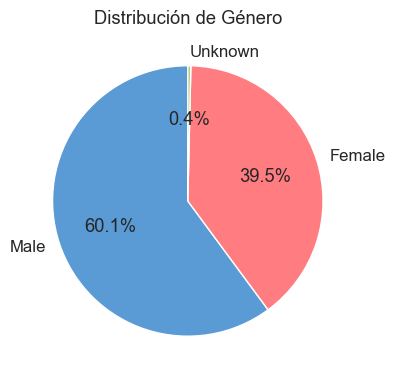

In [509]:
# ── Variable 13: Gender ───────────────────────────────────────────────────
print('VARIABLE 13 — Gender')
print(df['Gender'].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(6, 4))
vals = df['Gender'].value_counts()
ax.pie(vals, labels=vals.index, autopct='%1.1f%%', startangle=90,
       colors=['#5b9bd5', '#ff7c80', '#a9d18e'])
ax.set_title('Distribución de Género')
plt.tight_layout()
plt.show()

Variable 13: Gender 
  21 registros "Unknown" (0.36%) → revisar si hay que imputar o mantener como categoría.
  → Variable relevante para análisis de equidad y para el modelo.

VARIABLE 14 — Marital Status
Marital Status
Single        3510
Free Union    1105
Married        792
Common Law     173
Unknown        126
Divorced        77
Widowed          5
Partner          3
NaN              1
Name: count, dtype: int64


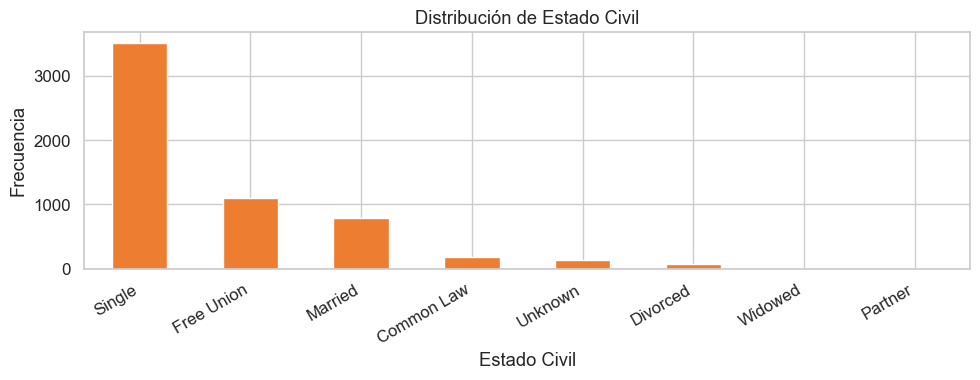

In [510]:
# ── Variable 14: Marital Status ───────────────────────────────────────────
print('VARIABLE 14 — Marital Status')
print(df['Marital Status'].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(10, 4))
df['Marital Status'].value_counts().plot(kind='bar', ax=ax, color='#ed7d31')
ax.set_title('Distribución de Estado Civil')
ax.set_xlabel('Estado Civil')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print()


Variable 14: Marital Status
→ "Common Law" y "Free Union" son similares jurídicamente; considerar unificar.
→ 1 nulo → imputar con moda o categoría "Unknown".

VARIABLES 15, 16 — Area y Grouped Department Name


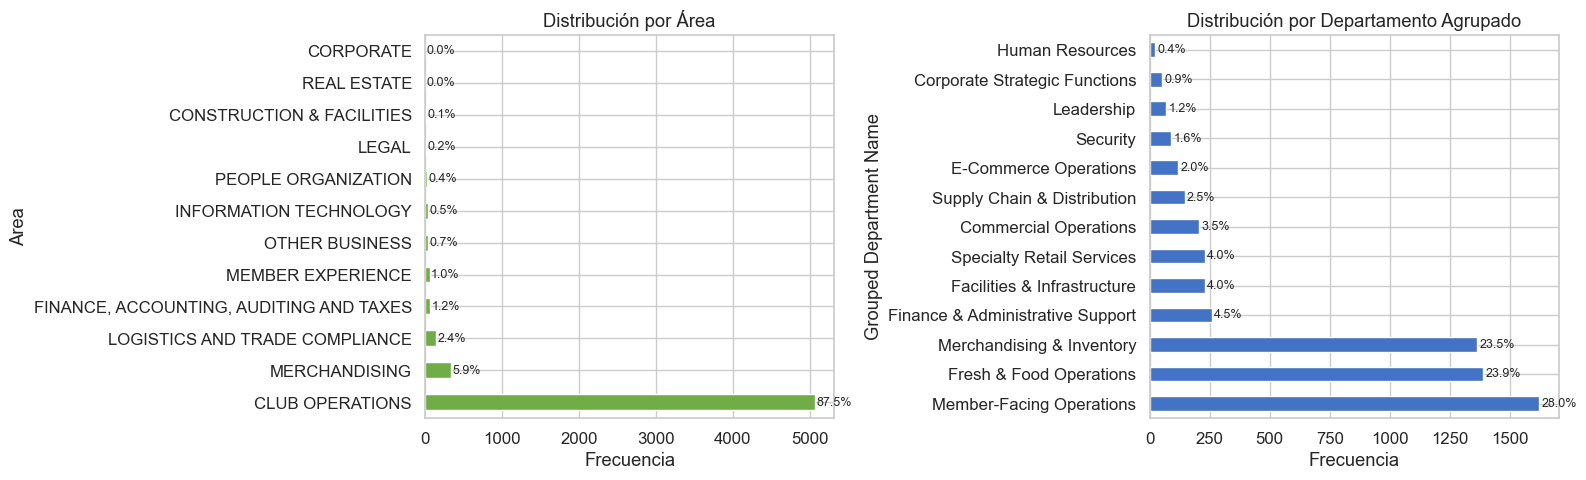

In [511]:
# ── Variables 15-16: Area y Grouped Department Name ──────────────────────
print('VARIABLES 15, 16 — Area y Grouped Department Name')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

area_counts = df['Area'].value_counts()
area_counts.plot(kind='barh', ax=axes[0], color='#70ad47')
axes[0].set_title('Distribución por Área')
axes[0].set_xlabel('Frecuencia')
for i, v in enumerate(area_counts):
    axes[0].text(v + 20, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

dept_counts = df['Grouped Department Name'].value_counts()
dept_counts.plot(kind='barh', ax=axes[1], color='#4472c4')
axes[1].set_title('Distribución por Departamento Agrupado')
axes[1].set_xlabel('Frecuencia')
for i, v in enumerate(dept_counts):
    axes[1].text(v + 10, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print()

VARIABLE 17 — Job Level
Job Level
1     1244
2     1739
3      739
4      767
5      645
6      162
7      351
8       69
9       26
10      34
11      10
12       2
13       2
15       1
16       1
Name: count, dtype: int64


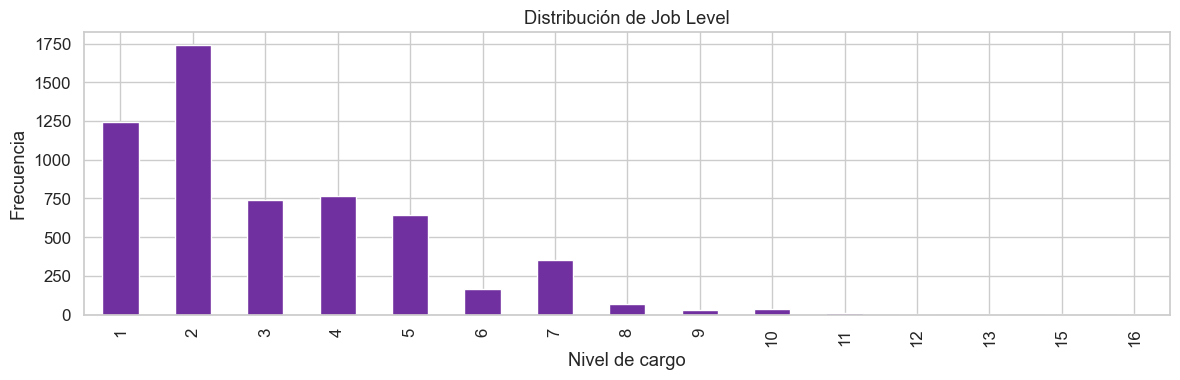

In [512]:
# ── Variable 17: Job Level ────────────────────────────────────────────────
print('VARIABLE 17 — Job Level')
print(df['Job Level'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(12, 4))
df['Job Level'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#7030a0')
ax.set_title('Distribución de Job Level')
ax.set_xlabel('Nivel de cargo')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


 Variable 17: Job Level
 puede llegar a ser muy importante en el modelo (nivel de cargo vs rotación). Se puede considerar agruar bajo categorias de técnico, tecnologo, profesional, jefes, etc.

VARIABLES 18, 19 — Location Description y Type Location


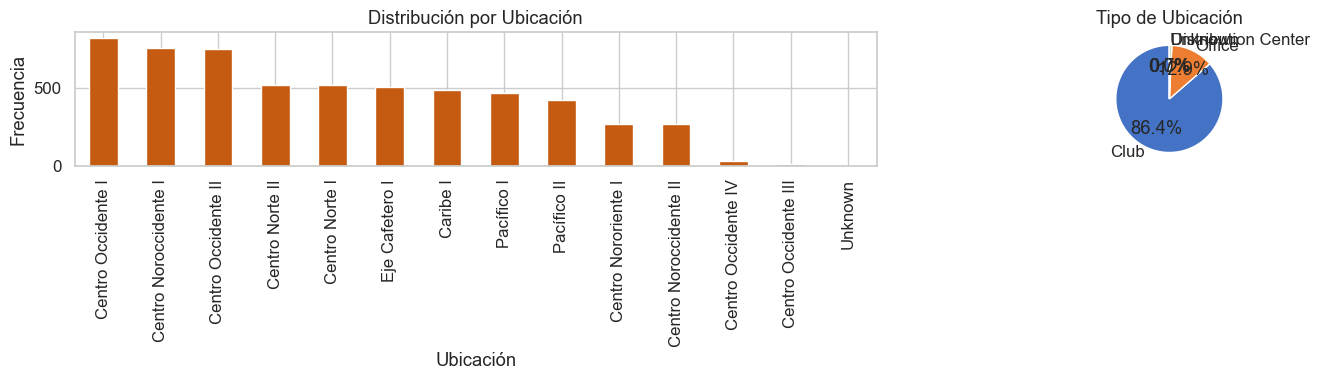

Type Location        Type   
Club                 C          5003
Distribution Center  D            42
Office               O           746
Unknown              Unknown       1


In [513]:
# ── Variables 18-19: Location Description y Type Location ─────────────────
print('VARIABLES 18, 19 — Location Description y Type Location')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

loc_counts = df['Location Description'].value_counts()
loc_counts.plot(kind='bar', ax=axes[0], color='#c55a11')
axes[0].set_title('Distribución por Ubicación')
axes[0].set_xlabel('Ubicación')
axes[0].set_ylabel('Frecuencia')

type_loc_counts = df['Type Location'].value_counts()
axes[1].pie(type_loc_counts, labels=type_loc_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#4472c4', '#ed7d31', '#a9d18e', '#ffc000'])
axes[1].set_title('Tipo de Ubicación')

plt.tight_layout()
plt.show()

print(df.groupby('Type Location')['Type'].value_counts().to_string())

Variables 18-19: Location Description y Type Location
→ Type Location y la columna "Type" son redundantes (C=Club, O=Office, D=Distribution).
→ Verificar cruce

VARIABLE 20 — Contract Type
Contract Type
Full Time    5590
Part Time     202
Name: count, dtype: int64

VARIABLE 21 — Exchange Rate (TRM USD/COP)
count   5792.0000
mean    3695.4444
std      457.4823
min     2705.7500
25%     3421.0550
50%     3765.9200
75%     3909.5125
max     5104.0000
Name: Exchange Rate, dtype: float64


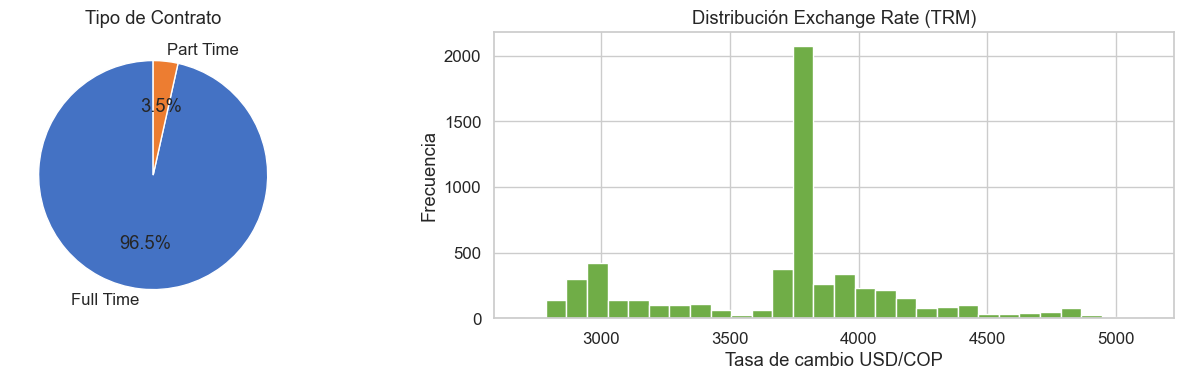

In [514]:
# ── Variables 20-21: Contract Type y Exchange Rate ─────────────────────────
print('VARIABLE 20 — Contract Type')
print(df['Contract Type'].value_counts())
print()
print('VARIABLE 21 — Exchange Rate (TRM USD/COP)')
print(df['Exchange Rate'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ct_counts = df['Contract Type'].value_counts()
axes[0].pie(ct_counts, labels=ct_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4472c4', '#ed7d31'])
axes[0].set_title('Tipo de Contrato')

df['Exchange Rate'].hist(bins=30, ax=axes[1], color='#70ad47', edgecolor='white')
axes[1].set_title('Distribución Exchange Rate (TRM)')
axes[1].set_xlabel('Tasa de cambio USD/COP')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


Variables 20-21: Contract Type y Exchange Rate
Contract Type: mayoría Full Time (96.5%).
Exchange Rate: varía entre 2,700 y 5,100 → refleja cambio en el tiempo (ligado a Hire Date)
→ Exchange Rate = TRM a la fecha de contratación; correlacionada con Hire Date.

VARIABLE 22 — Type
Type
C          5003
O           746
D            42
Unknown       1
Name: count, dtype: int64

VARIABLE 23 — Termination Reason
  Nulos: 1895 (empleados activos)
Termination Reason
Better Job Opp (Voluntary)        663
Other **EXPLAIN IN COMMENTS**     407
Family (Voluntary)                399
Personal** DO NOT USE** (Vol)     367
Violation of Policy (Involun)     296
Reduction in Force (Involun)      283
Unable to meet job requirement    275
Unwilling to meet job req.        205
Unwilling to meet req (Inv)       169
Relocation(Voluntary)             152
Insubordination (Involuntary)     123
Unknown (Voluntary)               108
School (Voluntary)                 83
Boredom (Voluntary)                71
Work Environment (Voluntary)       55
Name: count, dtype: int64

VARIABLE 24 — Termination Type
Termination Type
Voluntary      2021
Unknown        1895
Involuntary    1876
Name: count, dtype: int64


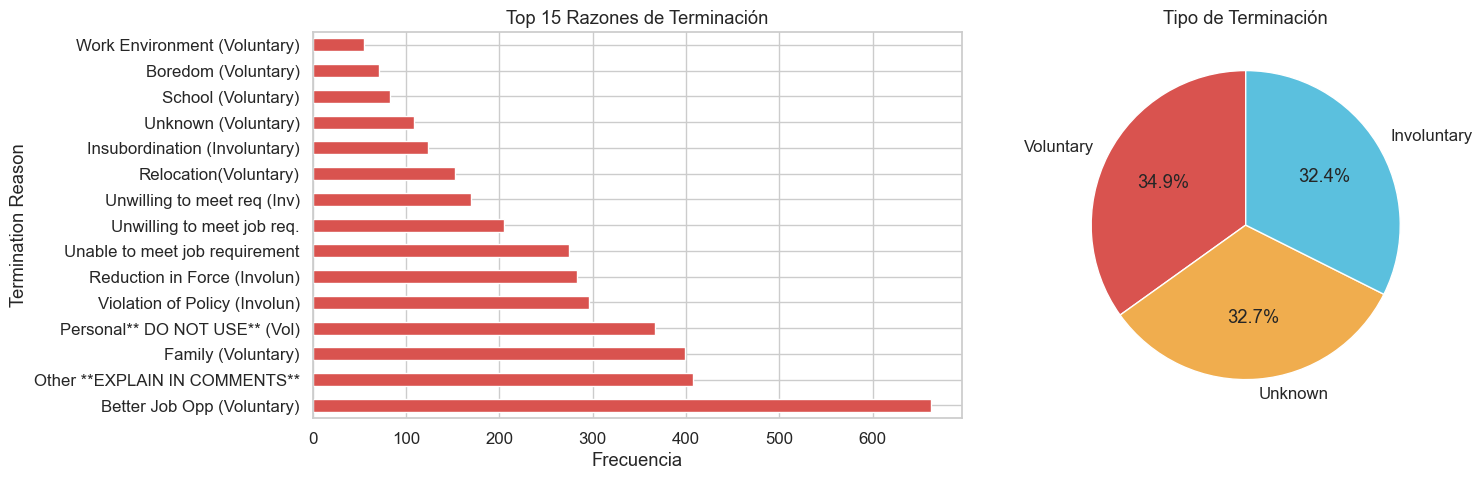

In [515]:
# ── Variables 22-24: Type, Termination Reason, Termination Type ──────────
print('VARIABLE 22 — Type')
print(df['Type'].value_counts())
print()
print('VARIABLE 23 — Termination Reason')
print(f'  Nulos: {df["Termination Reason"].isnull().sum()} (empleados activos)')
print(df['Termination Reason'].value_counts().head(15))
print()
print('VARIABLE 24 — Termination Type')
print(df['Termination Type'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Termination Reason - solo retirados
term_reason = df[df['Termination Reason'].notna()]['Termination Reason'].value_counts().head(15)
term_reason.plot(kind='barh', ax=axes[0], color='#d9534f')
axes[0].set_title('Top 15 Razones de Terminación')
axes[0].set_xlabel('Frecuencia')

# Termination Type
tt_counts = df['Termination Type'].value_counts()
axes[1].pie(tt_counts, labels=tt_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#d9534f', '#f0ad4e', '#5bc0de'])
axes[1].set_title('Tipo de Terminación')

plt.tight_layout()
plt.show()

Variables 22-24: Type, Termination Reason, Termination Type
"Unknown" en Termination Type = empleados activos (1,895 registros).')
→ Termination Reason tiene 34 categorías — agrupar en: Voluntaria, Involuntaria, Desconocida.')
→ "Type" (C/O/D/Unknown) duplica Type Location → candidata a eliminación.')

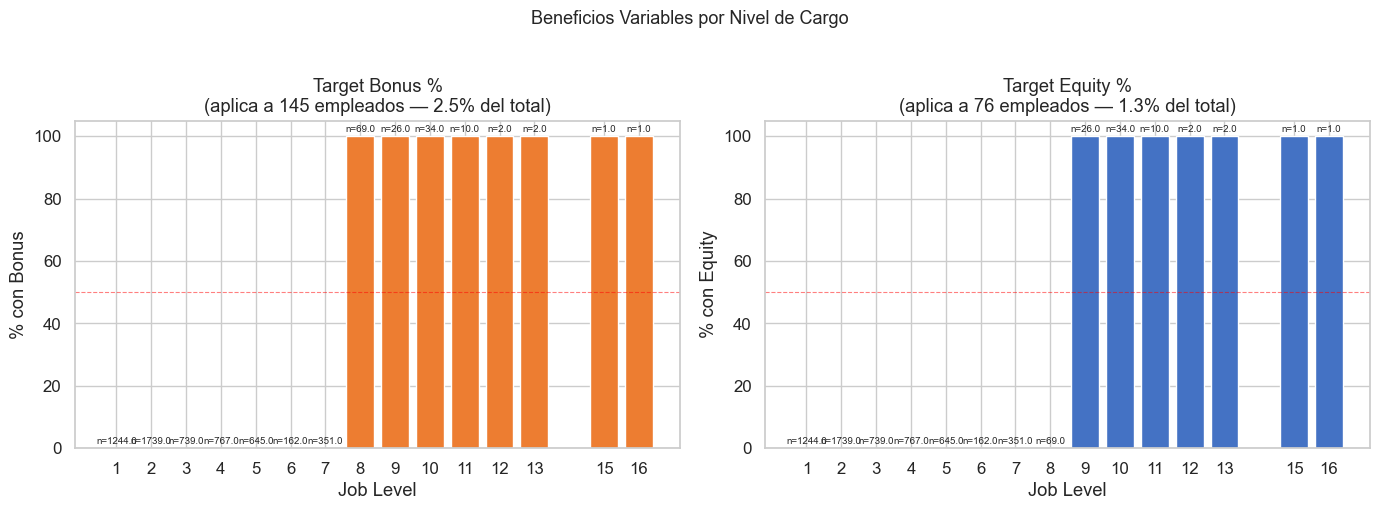

Tasa de rotación según aplica o no el beneficio:
  Con Bonus:    32.4%
  Sin Bonus:    68.2%
  Con Equity:   40.8%
  Sin Equity:   67.6%


In [516]:
# ── Variables 25, 30: Target Bonus % y Target Equity % ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bonus ──
bonus_by_level = df.groupby('Job Level').agg(
    total=('Target Bonus %', 'count'),
    tiene_bonus=('Target Bonus %', lambda x: (x > 0).sum()),
    pct=('Target Bonus %', lambda x: round((x > 0).mean() * 100, 1))
).reset_index()

colors_bonus = ['#ed7d31' if p > 0 else '#d9d9d9' for p in bonus_by_level['pct']]
axes[0].bar(bonus_by_level['Job Level'], bonus_by_level['pct'], color=colors_bonus)
axes[0].axhline(y=50, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title(f'Target Bonus %\n(aplica a {(df["Target Bonus %"] > 0).sum()} empleados — 2.5% del total)')
axes[0].set_xlabel('Job Level')
axes[0].set_ylabel('% con Bonus')
axes[0].set_xticks(bonus_by_level['Job Level'])

# Anotar el n por barra
for _, row in bonus_by_level.iterrows():
    axes[0].text(row['Job Level'], row['pct'] + 1.5, f"n={row['total']}", 
                 ha='center', fontsize=7)

# ── Equity ──
equity_by_level = df.groupby('Job Level').agg(
    total=('Target Equity %', 'count'),
    tiene_equity=('Target Equity %', lambda x: (x > 0).sum()),
    pct=('Target Equity %', lambda x: round((x > 0).mean() * 100, 1))
).reset_index()

colors_eq = ['#4472c4' if p > 0 else '#d9d9d9' for p in equity_by_level['pct']]
axes[1].bar(equity_by_level['Job Level'], equity_by_level['pct'], color=colors_eq)
axes[1].axhline(y=50, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_title(f'Target Equity %\n(aplica a {(df["Target Equity %"] > 0).sum()} empleados — 1.3% del total)')
axes[1].set_xlabel('Job Level')
axes[1].set_ylabel('% con Equity')
axes[1].set_xticks(equity_by_level['Job Level'])

for _, row in equity_by_level.iterrows():
    axes[1].text(row['Job Level'], row['pct'] + 1.5, f"n={row['total']}", 
                 ha='center', fontsize=7)

plt.suptitle('Beneficios Variables por Nivel de Cargo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Tabla resumen con tasa de rotación ──
df['rotacion'] = (df['Active Employee'] == 'N').astype(int)
print("Tasa de rotación según aplica o no el beneficio:")
print(f"  Con Bonus:    {df[df['Target Bonus %']>0]['rotacion'].mean()*100:.1f}%")
print(f"  Sin Bonus:    {df[df['Target Bonus %']==0]['rotacion'].mean()*100:.1f}%")
print(f"  Con Equity:   {df[df['Target Equity %']>0]['rotacion'].mean()*100:.1f}%")
print(f"  Sin Equity:   {df[df['Target Equity %']==0]['rotacion'].mean()*100:.1f}%")


Variables 25, 30: Target Bonus % y Target Equity %: Se refiere al % de bono anual que recibiria una persona si aplica (Target bonus) y al % de bono variable de una persona si aplica.
→ Crear variables binarias: has_bonus y has_equity para mejor representación.

VARIABLE 26 — Non Exempt (exento de horas extras)
Non Exempt
Non Exempt    2905
Exempt        2887
Name: count, dtype: int64

VARIABLE 27 — Active Employee (VARIABLE OBJETIVO)
Active Employee
N    3897
Y    1895
Name: count, dtype: int64
  Tasa de rotación: 67.3%


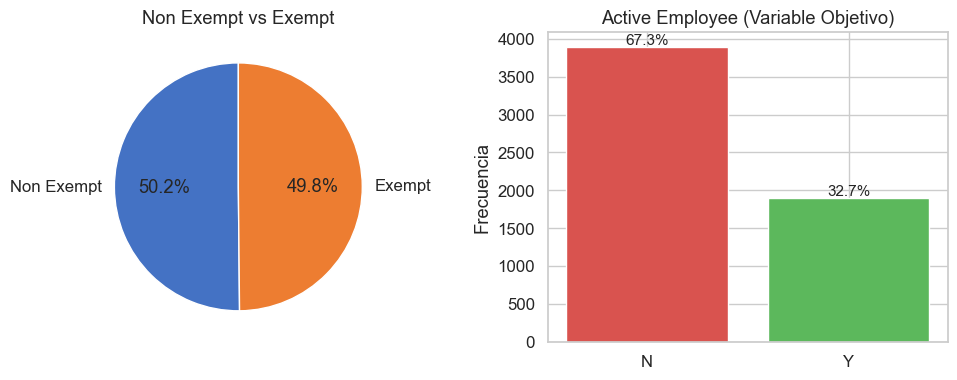

In [517]:
# ── Variables 26, 27: Non Exempt y Active Employee ─────────────────────────
print('VARIABLE 26 — Non Exempt (exento de horas extras)')
print(df['Non Exempt'].value_counts())
print()
print('VARIABLE 27 — Active Employee (VARIABLE OBJETIVO)')
print(df['Active Employee'].value_counts())
print(f'  Tasa de rotación: {(df["Active Employee"] == "N").mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ne_counts = df['Non Exempt'].value_counts()
axes[0].pie(ne_counts, labels=ne_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4472c4', '#ed7d31'])
axes[0].set_title('Non Exempt vs Exempt')

ae_counts = df['Active Employee'].value_counts()
axes[1].bar(ae_counts.index, ae_counts.values, color=['#d9534f', '#5cb85c'])
axes[1].set_title('Active Employee (Variable Objetivo)')
axes[1].set_ylabel('Frecuencia')
for i, (k, v) in enumerate(ae_counts.items()):
    axes[1].text(i, v + 30, f'{v/len(df)*100:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Variables 26, 27: Non Exempt y Active Employee
→ Active Employee = N: son los que han rotado
→ Dataset con clases relativamente balanceadas.

En cuantyo a Exempt y Non Exempt, se refiere a si las personas está habilitadas para generar horas extras y recibir pago de ello

VARIABLE 28 — Hire Date
  Rango: 1998-11-02 a 2025-12-19
  Tipo: datetime64[ns]

VARIABLE 29 — Termination Date
  Tipo raw: object
  Valores únicos (muestra): [datetime.datetime(2013, 9, 27, 0, 0) datetime.time(0, 0)
 datetime.datetime(2014, 8, 27, 0, 0) datetime.datetime(2013, 4, 15, 0, 0)
 datetime.datetime(2015, 7, 9, 0, 0) datetime.datetime(2014, 10, 15, 0, 0)
 datetime.datetime(2014, 2, 18, 0, 0) datetime.datetime(2013, 6, 1, 0, 0)
 datetime.datetime(2013, 7, 22, 0, 0) datetime.datetime(2014, 2, 15, 0, 0)]
  Nulos tras conversión: 1895


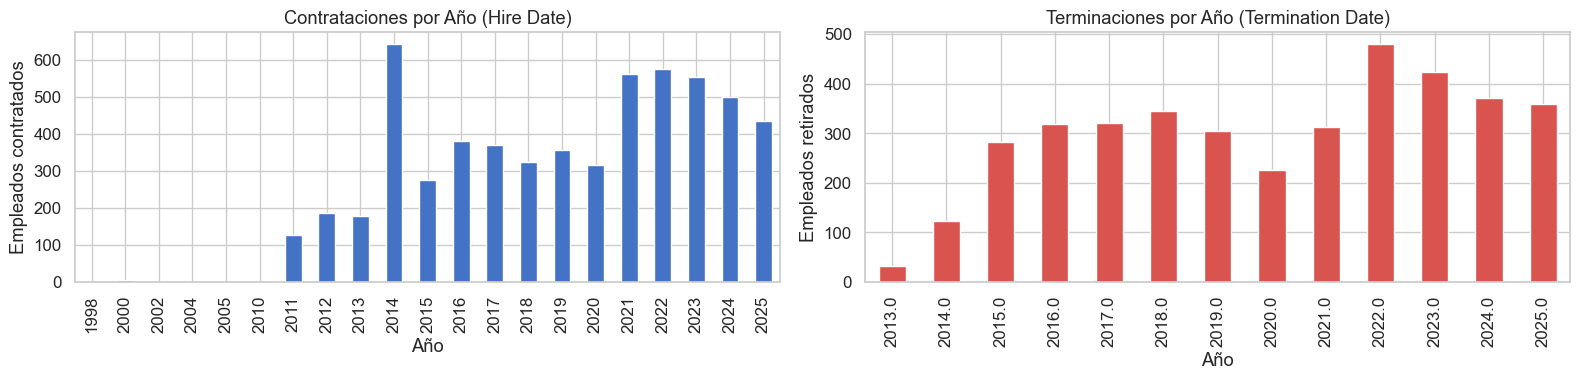

In [518]:
# ── Variables 28, 29: Hire Date y Termination Date ────────────────────────
print('VARIABLE 28 — Hire Date')
print(f'  Rango: {df["Hire Date"].min().date()} a {df["Hire Date"].max().date()}')
print(f'  Tipo: {df["Hire Date"].dtype}')

print()
print('VARIABLE 29 — Termination Date')
print(f'  Tipo raw: {df["Termination Date"].dtype}')
print(f'  Valores únicos (muestra): {df["Termination Date"].unique()[:10]}')

# Convertir Termination Date
df['Termination Date Clean'] = pd.to_datetime(df['Termination Date'], errors='coerce')
# Valores que son solo hora '00:00:00' corresponden a empleados activos
print(f'  Nulos tras conversión: {df["Termination Date Clean"].isnull().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df['Hire Date'].dt.year.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4472c4')
axes[0].set_title('Contrataciones por Año (Hire Date)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Empleados contratados')

df['Termination Date Clean'].dt.year.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#d9534f')
axes[1].set_title('Terminaciones por Año (Termination Date)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Empleados retirados')

plt.tight_layout()
plt.show()


Variables 28, 29: Hire Date y Termination Date
→ Hire Date está limpio (datetime64). Termination Date tiene mezcla de fechas y timestamps vacíos.
→ Ambas son clave para calcular ANTIGÜEDAD. y si pasó o no el periodo de prueba, hau una vaiable que lo indica, pero se debe validar que esté boien (periodo de prueba 2 meses)

VARIABLE 31 — Standardized_Salary
count   5792.0000
mean      -0.0000
std        1.0000
min       -0.5753
25%       -0.3630
50%       -0.2107
75%       -0.0552
max       20.7953
Name: Standardized_Salary, dtype: float64

  Media ≈ 0, Std ≈ 1 → ya está estandarizada (Z-score).
  Mínimo: -0.575 | Máximo: 20.795
  Outliers (|z| > 3): 98 registros


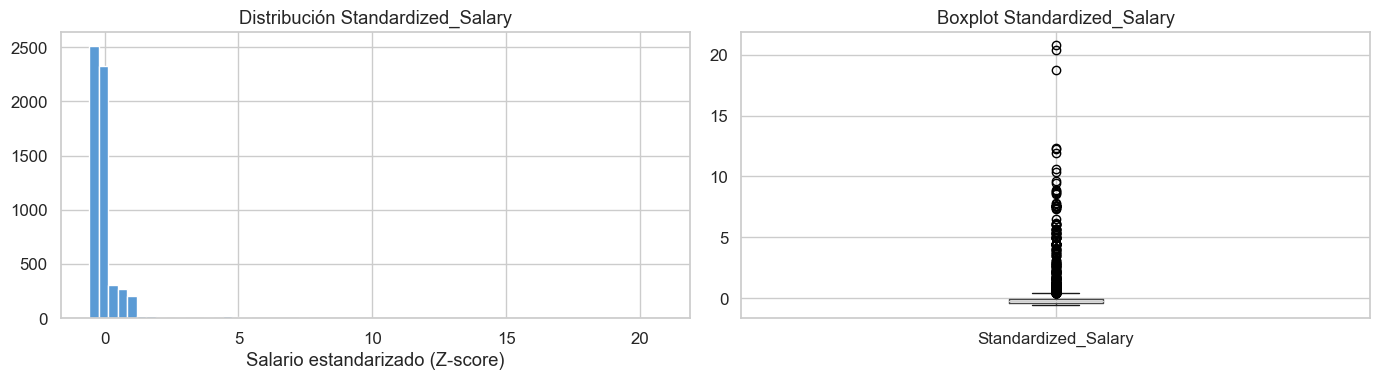

In [519]:
# ── Variable 31: Standardized_Salary ──────────────────────────────────────
print('VARIABLE 31 — Standardized_Salary')
print(df['Standardized_Salary'].describe())
print()
print(f'  Media ≈ 0, Std ≈ 1 → ya está estandarizada (Z-score).')
print(f'  Mínimo: {df["Standardized_Salary"].min():.3f} | Máximo: {df["Standardized_Salary"].max():.3f}')
print(f'  Outliers (|z| > 3): {(df["Standardized_Salary"].abs() > 3).sum()} registros')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Standardized_Salary'].hist(bins=60, ax=axes[0], color='#5b9bd5', edgecolor='white')
axes[0].set_title('Distribución Standardized_Salary')
axes[0].set_xlabel('Salario estandarizado (Z-score)')
df.boxplot(column='Standardized_Salary', ax=axes[1])
axes[1].set_title('Boxplot Standardized_Salary')
plt.tight_layout()
plt.show()


Variable 31: Standardized_Salary
→ Distribución sesgada a la derecha (unos pocos ejecutivos con salarios muy altos).
→ Variable predictiva clave: salario relativo vs rotación.

In [520]:
# ── Variables 32-35: Datos del Supervisor ────────────────────────────────
print('VARIABLES 32-35 — Supervisor (Active Supervisor, Code, Dept, Job ID)')
print()
print('Active Supervisor:')
print(df['Active Supervisor'].value_counts())
print()
print('Supervisor Code (top 10):')
print(df['Supervisor Code'].value_counts().head(10))
print()
print('Gropued Supervisor Department:')
print(df['Gropued Supervisor Department'].value_counts())
print()
print('Supervisor Job ID (top 10):')
print(df['Supervisor Job ID'].value_counts().head(10))


VARIABLES 32-35 — Supervisor (Active Supervisor, Code, Dept, Job ID)

Active Supervisor:
Active Supervisor
Y    3924
N    1868
Name: count, dtype: int64

Supervisor Code (top 10):
Supervisor Code
Inactive     1868
EMP_01768     113
EMP_01553      84
EMP_02410      72
EMP_00980      67
EMP_01352      64
EMP_00185      59
EMP_00013      59
EMP_00431      58
EMP_01000      56
Name: count, dtype: int64

Gropued Supervisor Department:
Gropued Supervisor Department
Inactive                            1868
Member-Facing Operations             749
Leadership                           739
Merchandising & Inventory            664
Fresh & Food Operations              644
Finance & Administrative Support     229
Other / Non-Operational              222
Commercial Operations                194
Supply Chain & Distribution          117
Facilities & Infrastructure           96
Corporate Strategic Functions         89
Specialty Retail Services             53
E-Commerce Operations                 50
Hum

Variables 32-35: Datos del Supervisor
→ Supervisor Code tiene valor "Inactive" cuando el supervisor ya no está activo (1,868 casos).
→ Active Supervisor Y/N puede ser relevante: tener un jefe activo vs. inactivo.
→ Supervisor Code tiene alta cardinalidad (354 únicos) — usar Active Supervisor o Dept del supervisor.

In [521]:
# ── Variable 36: Probation Period Completed ───────────────────────────────
print('VARIABLE 36 — Probation Period Completed')
print(df['Probation Period Completed'].value_counts())
pct_yes = (df['Probation Period Completed'] == 'Yes').mean() * 100


VARIABLE 36 — Probation Period Completed
Probation Period Completed
Yes    5743
No       49
Name: count, dtype: int64


Variable 36: Probation Period Completed
Esta es la variable que idgo que hay que revisar con detalle, a partir de la fecha de contratación y terminación, porque puede estar mal

VARIABLE 37 — Position vs Estimated Median
count   5792.0000
mean       0.9240
std        0.1345
min        0.3440
25%        0.8565
50%        0.9166
75%        0.9596
max        2.2755
Name: Position vs Estimated Median, dtype: float64
  Nulos: 0 (0.0%)


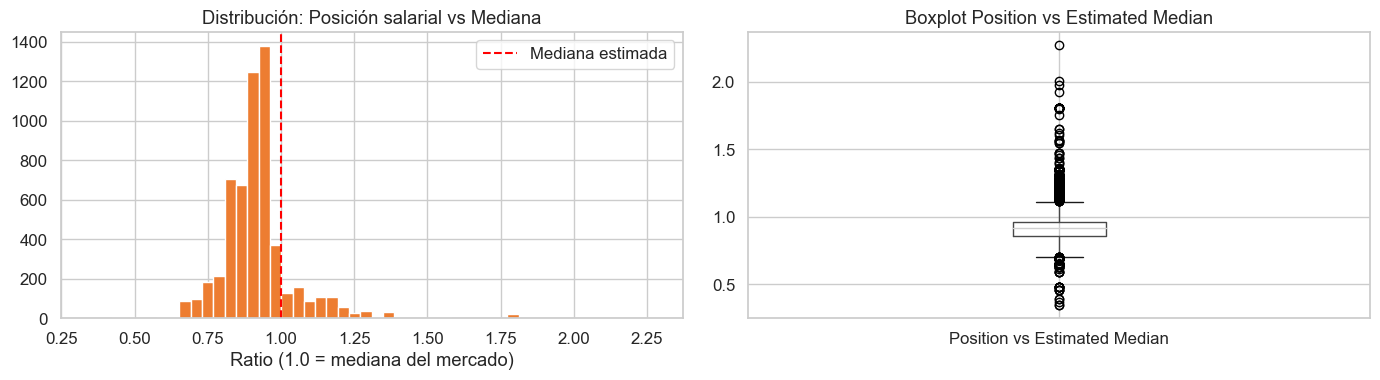


  → Variable muy relevante: qué tan competitivo es el salario vs el mercado.
  → personas debajo de 1.0 → sugiere que muchos empleados ganan por debajo de la mediana de mercado.
  → es una banda salarial, que va del 80% ¨(piso de la banda), al 120% (techo de la banda).


In [522]:
# ── Variable 37: Position vs Estimated Median ─────────────────────────────
print('VARIABLE 37 — Position vs Estimated Median')
print(df['Position vs Estimated Median'].describe())
print(f'  Nulos: {df["Position vs Estimated Median"].isnull().sum()} ({df["Position vs Estimated Median"].isnull().mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Position vs Estimated Median'].hist(bins=50, ax=axes[0], color='#ed7d31', edgecolor='white')
axes[0].axvline(1.0, color='red', linestyle='--', label='Mediana estimada')
axes[0].set_title('Distribución: Posición salarial vs Mediana')
axes[0].set_xlabel('Ratio (1.0 = mediana del mercado)')
axes[0].legend()
df.boxplot(column='Position vs Estimated Median', ax=axes[1])
axes[1].set_title('Boxplot Position vs Estimated Median')
plt.tight_layout()
plt.show()

print()
print('  → Variable muy relevante: qué tan competitivo es el salario vs el mercado.')
print('  → personas debajo de 1.0 → sugiere que muchos empleados ganan por debajo de la mediana de mercado.')
print('  → es una banda salarial, que va del 80% ¨(piso de la banda), al 120% (techo de la banda).')

In [523]:
#edad:
# ── Identificar registros con edad inconsistente ──
df['Hire Date'] = pd.to_datetime(df['Hire Date'])

problemas_edad = pd.concat([
    # Nulos
    df[df['AGE'].isnull()][['Employee Code','AGE','Hire Date','Active Employee','Job Level','Area']].assign(problema='AGE nula'),
    # Cero (imposible trabajar a los 0 años)
    df[df['AGE'] == 0][['Employee Code','AGE','Hire Date','Active Employee','Job Level','Area']].assign(problema='AGE = 0'),
    # Menores de edad (< 18)
    df[(df['AGE'] > 0) & (df['AGE'] < 18)][['Employee Code','AGE','Hire Date','Active Employee','Job Level','Area']].assign(problema='AGE < 18'),
    # Edad extremadamente alta (> 65 como umbral de revisión)
    df[df['AGE'] > 65][['Employee Code','AGE','Hire Date','Active Employee','Job Level','Area']].assign(problema='AGE > 65')
])

print(f"Total registros con inconsistencia en AGE: {len(problemas_edad)}")
print(problemas_edad.to_string(index=False))

Total registros con inconsistencia en AGE: 5
Employee Code     AGE  Hire Date Active Employee  Job Level                           Area problema
    EMP_05551     NaN 2025-05-21               N          5 LOGISTICS AND TRADE COMPLIANCE AGE nula
    EMP_01318  0.0000 2015-07-16               N          1                CLUB OPERATIONS  AGE = 0
    EMP_04077  0.0000 2022-07-16               N          1                CLUB OPERATIONS  AGE = 0
    EMP_05784  0.0000 2025-12-15               Y          1                CLUB OPERATIONS  AGE = 0
    EMP_01416 67.0000 2015-12-17               N          3                CLUB OPERATIONS AGE > 65


---
## 5. Limpieza de las variables 

##filtro que solo queden full time

Con solo 202 Part Time vs 5.590 Full Time la proporción es:

Part Time:  3.5%
Full Time: 96.5%

Con apenas un 3.5% de Part Time, el modelo tendría muy pocos ejemplos para aprender patrones de ese grupo. Lo más recomendable es quedarse solo con Full Time así el modelo será más preciso y los resultados más interpretables para la empresa.
La rotación tiene patrones muy diferentes entre Full Time y Part Time — mezclarlos puede confundir al modelo
Los Part Time suelen tener mayor rotación esperada por naturaleza del contrato, no por factores que el modelo pueda predecir
Las variables como Hours/ Week, Salary, Antigüedad son más comparables entre sí cuando todos son Full Time
El modelo aprende patrones más limpios y consistentes

In [524]:
# Filtrar solo Full Time
df_fulltime = df[df['Contract Type'] == 'Full Time'].copy()

print(f"Registros originales:  {len(df)}")
print(f"Registros eliminados:  {len(df) - len(df_fulltime)}  (Part Time)")
print(f"Registros Full Time:   {len(df_fulltime)}")

# Verificar que no quedó ningún Part Time
print("\nVerificación Contract Type:")
print(df_fulltime['Contract Type'].value_counts())

Registros originales:  5792
Registros eliminados:  202  (Part Time)
Registros Full Time:   5590

Verificación Contract Type:
Contract Type
Full Time    5590
Name: count, dtype: int64


---
### LIMPIEZA VARIABLE Hours/ Week
Ya no se requiere, porque no vamos a tener en cuenta trabajadores part time, por lo que la variable se elimina del modelo

In [525]:
FFECHA_CORTE = pd.Timestamp('2025-12-31')

df_fulltime['Hire Date'] = pd.to_datetime(df_fulltime['Hire Date'], errors='coerce')
df_fulltime['Hire Year'] = df_fulltime['Hire Date'].dt.year

# Definir rango válido por año
def horas_validas(year):
    if year <= 2022: return (40, 48)
    elif year == 2023: return (40, 47)
    elif year == 2024: return (40, 46)
    else: return (40, 44)

# Recalcular mask_atipicos sobre df_fulltime
mask_atipicos = df_fulltime.apply(
    lambda row: not (horas_validas(row['Hire Year'])[0]
                     <= row['Hours/ Week']
                     <= horas_validas(row['Hire Year'])[1]),
    axis=1
)

# Función de imputación por año
def max_horas_por_año(year):
    if year <= 2022: return 48
    elif year == 2023: return 47
    elif year == 2024: return 46
    else: return 44

# Aplicar corrección solo sobre Full Time
df_fulltime.loc[mask_atipicos, 'Hours/ Week'] = df_fulltime.loc[mask_atipicos, 'Hire Year'].apply(max_horas_por_año)

# Verificar
print(f"Total registros Full Time: {len(df_fulltime)}")
print(f"Atípicos corregidos: {mask_atipicos.sum()}")
print("\nDistribución final corregida:")
print(df_fulltime['Hours/ Week'].value_counts().sort_index())

Total registros Full Time: 5590
Atípicos corregidos: 123

Distribución final corregida:
Hours/ Week
40       1
44    2008
46     341
47     358
48    2882
Name: count, dtype: int64


In [526]:
# Para el valor de 40 horas que es solo 1, se realiza imputación de acuerdo con el máximo legal de su año
mask_40 = df_fulltime['Hours/ Week'] == 40
print(df_fulltime.loc[mask_40, ['Hire Year', 'Hours/ Week']])  # Ver de qué año es

df_fulltime.loc[mask_40, 'Hours/ Week'] = df_fulltime.loc[mask_40, 'Hire Year'].apply(max_horas_por_año)

# Verificar que ya no existe el valor 40
print("\nDistribución final:")
print(df_fulltime['Hours/ Week'].value_counts().sort_index())

      Hire Year  Hours/ Week
4383       2023           40

Distribución final:
Hours/ Week
44    2008
46     341
47     359
48    2882
Name: count, dtype: int64


VARIABLE 3 — Hours/Week (Solo Full Time)
             count
Hours/ Week       
48            2882
44            2008
47             359
46             341

  Media: 46.4 | Mín: 44 | Máx: 48


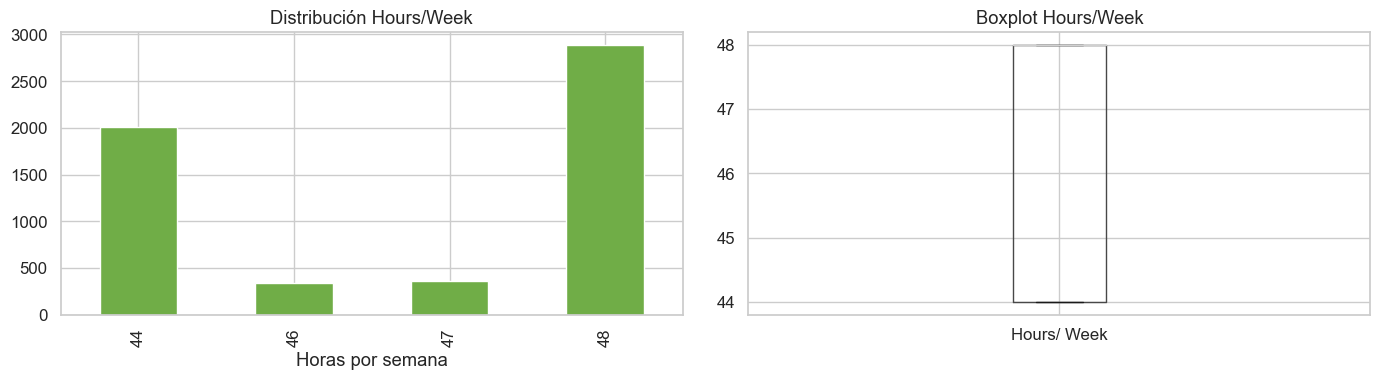

In [527]:
print('VARIABLE 3 — Hours/Week (Solo Full Time)')
print(df_fulltime['Hours/ Week'].value_counts().to_frame('count'))
print()
print(f'  Media: {df_fulltime["Hours/ Week"].mean():.1f} | Mín: {df_fulltime["Hours/ Week"].min()} | Máx: {df_fulltime["Hours/ Week"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_fulltime['Hours/ Week'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#70ad47')
axes[0].set_title('Distribución Hours/Week')
axes[0].set_xlabel('Horas por semana')
df_fulltime.boxplot(column='Hours/ Week', ax=axes[1])
axes[1].set_title('Boxplot Hours/Week')
plt.tight_layout()
plt.show()

### LIMPIEZA VARIABLE Marital Status
Para el modelo de rotación se recomienda que la variable sea binaria dado que La literatura en recursos humanos y estudios de rotación laboral consistentemente encuentra que:

Personas con pareja estable (casados o unión libre) tienden a tener menor rotación porque tienen mayor responsabilidad financiera del hogar, mayor aversión al riesgo de quedar desempleados y mayor estabilidad en rutinas y arraigo geográfico
Personas sin pareja (solteros, divorciados) tienden a tener mayor rotación porque tienen mayor movilidad y flexibilidad, menos compromisos financieros fijos y mayor disposición a tomar riesgos laborales
Tiene alta interpretabilidad, menor riesgo de Overfitting
Se recomienda no eliminar Marital Status original y conservar ambas variables para que el modelo decida cuál aporta más mediante la importancia de variables

In [528]:
df_fulltime['Tiene_Pareja'] = df_fulltime['Marital Status'].isin(['Married', 'Free Union']).astype(int)

# Verificar
print(df_fulltime['Tiene_Pareja'].value_counts())
print(f"\n  Con pareja (1): {df_fulltime['Tiene_Pareja'].sum()}")
print(f"  Sin pareja (0): {(df_fulltime['Tiene_Pareja'] == 0).sum()}")

Tiene_Pareja
0    3727
1    1863
Name: count, dtype: int64

  Con pareja (1): 1863
  Sin pareja (0): 3727


VARIABLE nueva Tiene_Pareja
Tiene_Pareja
0    3727
1    1863
Name: count, dtype: int64


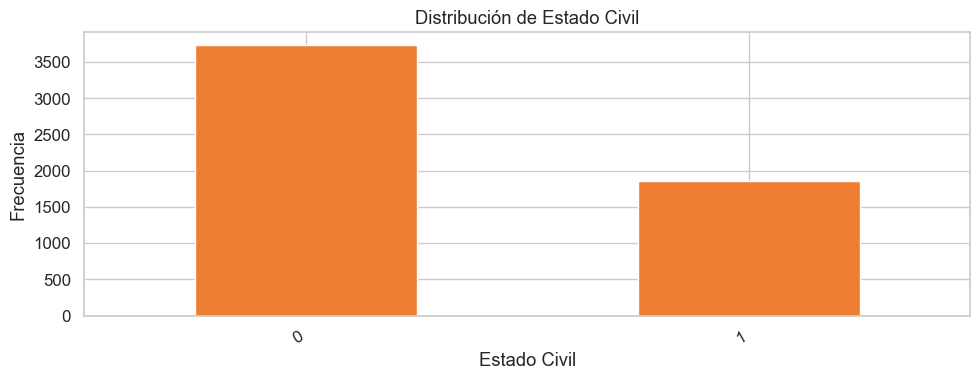

In [529]:
# ── Variable 14: Marital Status ───────────────────────────────────────────
print('VARIABLE nueva Tiene_Pareja')
print(df_fulltime['Tiene_Pareja'].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(10, 4))
df_fulltime['Tiene_Pareja'].value_counts().plot(kind='bar', ax=ax, color='#ed7d31')
ax.set_title('Distribución de Estado Civil')
ax.set_xlabel('Estado Civil')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print()

### LIMPIEZA VARIABLE Antigüedad

In [530]:
# Fecha de corte para empleados activos
FECHA_CORTE = pd.Timestamp('2025-12-31')

# Asegurar formato fecha
df_fulltime['Hire Date'] = pd.to_datetime(df_fulltime['Hire Date'], errors='coerce')
df_fulltime['Termination Date'] = pd.to_datetime(df_fulltime['Termination Date'], errors='coerce')

# Fecha final: Termination Date si existe, si no → fecha de corte
df_fulltime['Fecha_Fin'] = df_fulltime['Termination Date'].fillna(FECHA_CORTE)

# Calcular antigüedad solo en meses y años
df_fulltime['Antiguedad_Meses'] = ((df_fulltime['Fecha_Fin'] - df_fulltime['Hire Date']).dt.days / 30.44).round(1)
df_fulltime['Antiguedad_Anos']  = ((df_fulltime['Fecha_Fin'] - df_fulltime['Hire Date']).dt.days / 365.25).round(2)

# Verificar resultado
print(df_fulltime[['Hire Date', 'Termination Date', 'Fecha_Fin',
                   'Antiguedad_Meses', 'Antiguedad_Anos']].head(10))

print("\nEstadísticas de antigüedad (en años):")
print(df_fulltime['Antiguedad_Anos'].describe())

   Hire Date Termination Date  Fecha_Fin  Antiguedad_Meses  Antiguedad_Anos
0 2011-06-20       2013-09-27 2013-09-27           27.3000           2.2700
1 2011-07-15              NaT 2025-12-31          173.6000          14.4600
2 2011-07-11       2014-08-27 2014-08-27           37.5000           3.1300
3 2012-05-28       2013-04-15 2013-04-15           10.6000           0.8800
4 2012-05-30       2015-07-09 2015-07-09           37.3000           3.1100
5 2012-06-11       2014-10-15 2014-10-15           28.1000           2.3400
6 2012-06-11       2014-02-18 2014-02-18           20.3000           1.6900
7 2012-06-11       2013-06-01 2013-06-01           11.7000           0.9700
8 2012-06-11       2013-07-22 2013-07-22           13.3000           1.1100
9 2012-06-11              NaT 2025-12-31          162.6000          13.5600

Estadísticas de antigüedad (en años):
count   5590.0000
mean       2.8214
std        3.2348
min        0.0000
25%        0.5900
50%        1.6300
75%        3.7500

Para modelos de rotación, Antiguedad_Anos es la más usada porque la probabilidad de rotar suele tener un patrón claro por año: alta en el primer año, baja en años intermedios, y variable después de los 5 años.
Los resultados de las estadisticas en años evidencian que la mayoría de la rotación ocurre en los primeros 2 años, lo cual es un patrón muy común en recursos humanos y le dará mucho poder predictivo a esta variable.

In [531]:
# Ver cuántos y qué características tienen
mask_cero = df_fulltime['Antiguedad_Anos'] == 0
print(f"Registros con antigüedad 0: {mask_cero.sum()}")
print(df_fulltime.loc[mask_cero, ['Hire Date', 'Termination Date', 
                                   'Fecha_Fin', 'Antiguedad_Meses',
                                   'Antiguedad_Anos']].head(10))

Registros con antigüedad 0: 35
      Hire Date Termination Date  Fecha_Fin  Antiguedad_Meses  Antiguedad_Anos
265  2014-04-04       2014-04-04 2014-04-04            0.0000           0.0000
273  2014-01-17       2014-01-17 2014-01-17            0.0000           0.0000
1512 2016-06-20       2016-06-20 2016-06-20            0.0000           0.0000
1554 2016-06-07       2016-06-08 2016-06-08            0.0000           0.0000
1561 2016-07-16       2016-07-16 2016-07-16            0.0000           0.0000
1725 2016-09-27       2016-09-28 2016-09-28            0.0000           0.0000
1900 2017-03-03       2017-03-03 2017-03-03            0.0000           0.0000
2144 2017-11-14       2017-11-15 2017-11-15            0.0000           0.0000
2217 2018-02-01       2018-02-02 2018-02-02            0.0000           0.0000
2274 2018-03-02       2018-03-02 2018-03-02            0.0000           0.0000


Como hay 35 registros con antiguedad de cero, se evidencia que todos los casos tienen Hire Date = Termination Date o con 1 día de diferencia, lo que con el redondeo a 2 decimales queda en 0.00. Para un modelo de rotación estos registros no aportan información útil, un empleado que duró 0 o 1 día no tiene comportamiento laboral que el modelo pueda aprender. Lo más recomendable es eliminarlos porque son errores de registro con fecha igual de entrada y salida, probablemente un error en el sistema de RRHH.

¿Por qué eliminarlos y no imputarlos?
Imputar ¿Con qué valor? No hay forma de saber cuánto debieron durar
Dejar losIntroducen ruido — el modelo aprende que "durar 0 días" tiene algún patrón
Eliminar Son solo 35 de 5.590 registros (0.6%) — el impacto es mínimo y el modelo queda más limpio

_____________________________________________________________________________________________________________
Se identificaron 35 registros con antigüedad de 0 días (Hire Date = Termination Date)
o 1 día. El análisis de sus razones de terminación muestra que NO son necesariamente
errores de sistema: el 89% son salidas voluntarias (Job Abandonment, Better Job Opp,
Family), lo que corresponde al fenómeno real de "ghosting" o rechazo de oferta en el
primer día, común en operaciones de alto volumen de contratación.

Se tomó la decisión de eliminarlos porque:
1. El modelo está diseñado para predecir rotación en colaboradores que ya están
   integrados a la operación, no para el proceso de selección.
2. Representan solo el 0.6% de la base — el impacto en las métricas es mínimo.
3. No tienen variables de comportamiento laboral que el modelo pueda aprender
   (sin evaluaciones, sin interacciones con supervisor, sin historial).

Nota: si en el futuro se quisiera predecir el riesgo de "no-show" en nuevas
contrataciones, estos 35 registros serían la base de un modelo separado.

In [532]:
# Ver detalle completo antes de eliminar
print(f"Registros antes de eliminar: {len(df_fulltime)}")
print(f"Registros con antigüedad 0: {mask_cero.sum()}")

# Eliminar registros con antigüedad 0
df_fulltime = df_fulltime[df_fulltime['Antiguedad_Anos'] > 0].copy()

print(f"Registros después de eliminar: {len(df_fulltime)}")

# Verificar que ya no existen
print(f"\nVerificación — Registros con antigüedad 0: {(df_fulltime['Antiguedad_Anos'] == 0).sum()}")
print("\nNuevo mínimo de antigüedad:")
print(df_fulltime['Antiguedad_Anos'].describe())

Registros antes de eliminar: 5590
Registros con antigüedad 0: 35
Registros después de eliminar: 5555

Verificación — Registros con antigüedad 0: 0

Nuevo mínimo de antigüedad:
count   5555.0000
mean       2.8392
std        3.2371
min        0.0100
25%        0.6100
50%        1.6500
75%        3.7800
max       25.7100
Name: Antiguedad_Anos, dtype: float64


In [533]:
# Ver todas las columnas actuales
print(df_fulltime.columns.tolist())

['Employee Code', 'Termination Code', 'Hours/ Week', 'Currency Code', 'English Reading Lvl', 'English Spoken Lvl', 'English Writing Lvl', 'Spanish Reading Lvl', 'Spanish Spoken Lvl', 'Spanish Writing Lvl', 'Union', 'Employee Job ID', 'Gender', 'Marital Status', 'Area', 'Grouped Department Name', 'Job Level', 'Location Description', 'Type Location', 'Contract Type', 'Exchange Rate', 'Type', 'Termination Reason', 'Termination Type', 'Target Bonus %', 'Non Exempt', 'Active Employee', 'Hire Date', 'Termination Date', 'Target Equity %', 'Standardized_Salary', 'Active Supervisor', 'Supervisor Code', 'Gropued Supervisor Department', 'Supervisor Job ID', 'Probation Period Completed', 'Position vs Estimated Median', 'AGE', 'CPI', 'Cantidad Salarios Minimos', 'rotacion', 'Termination Date Clean', 'Hire Year', 'Tiene_Pareja', 'Fecha_Fin', 'Antiguedad_Meses', 'Antiguedad_Anos']


In [534]:
#Crear una variable flag: ¿el empleado está en su primer año?
#Dado que encontramos que la tasa de rotación en el primer año es del 83.7%, vale la pena capturar ese efecto explícitamente
df_fulltime['es_primer_anio'] = (df_fulltime['Antiguedad_Anos'] <= 1).astype(int)

print("Distribución es_primer_anio:")
print(df_fulltime['es_primer_anio'].value_counts())
print(f"\n  En primer año (1): {df_fulltime['es_primer_anio'].sum():,}")
print(f"  Más de un año (0): {(df_fulltime['es_primer_anio']==0).sum():,}")

Distribución es_primer_anio:
es_primer_anio
0    3560
1    1995
Name: count, dtype: int64

  En primer año (1): 1,995
  Más de un año (0): 3,560


### LIMPIEZA VARIABLE Periodo de prueba

In [535]:
FECHA_CORTE = pd.Timestamp('2025-12-31')
DIAS_PRUEBA = 61  # 2 meses ≈ 61 días

df_fulltime['Hire Date'] = pd.to_datetime(df_fulltime['Hire Date'], errors='coerce')
df_fulltime['Termination Date'] = pd.to_datetime(df_fulltime['Termination Date'], errors='coerce')

# Fecha fin: salida real o fecha de corte si está activo
df_fulltime['Fecha_Fin'] = df_fulltime['Termination Date'].fillna(FECHA_CORTE)

# Calcular días en la empresa
df_fulltime['Dias_Empresa'] = (df_fulltime['Fecha_Fin'] - df_fulltime['Hire Date']).dt.days

# Calcular si pasó el periodo de prueba
df_fulltime['PasoPeriodoPrueba_Calc'] = (df_fulltime['Dias_Empresa'] >= DIAS_PRUEBA).astype(int)

# Comparar con variable original
print("Variable original vs calculada:")
print(pd.crosstab(df_fulltime['Probation Period Completed'], 
                  df_fulltime['PasoPeriodoPrueba_Calc'], 
                  margins=True))

print("\nDistribución variable calculada:")
print(df_fulltime['PasoPeriodoPrueba_Calc'].value_counts())

Variable original vs calculada:
PasoPeriodoPrueba_Calc        0     1   All
Probation Period Completed                 
No                           47     0    47
Yes                         577  4931  5508
All                         624  4931  5555

Distribución variable calculada:
PasoPeriodoPrueba_Calc
1    4931
0     624
Name: count, dtype: int64


El 11.2% no pasó el periodo de prueba — es una señal muy fuerte de rotación temprana
Usar la variable original hubiera introducido ruido en el modelo con esos 577 mal clasificados
La variable calculada PasoPeriodoPrueba_Calc en lugar de la variable original para el modelo es más confiable al estar basada directamente en las fechas reales de entrada y salida.
Fila 1 — Los 47 marcados por la empresa como "no pasó" el cálculo confirma los 47 como No Coincidencia perfecta, sin discrepancias
Fila 2 — 4.931 confirmados como Yes por el cálculo 577 marcados como Yes por la empresa pero estuvieron menos de 61 días 
La variable original tiene un 10.4% de error — 577 empleados marcados como que sí pasaron la prueba cuando en realidad no completaron los 2 meses

In [536]:
# ── Variables 38-40: AGE, CPI ──────────────────────────────

Para la edad, podemos hacer agrupaciones: centenials, milenials, boomers, etc.

### LIMPIEZA Target equity y Target Bonus

In [537]:
###cambiar target equity a binario 
df_fulltime["Target_Equity_Binary"] = (df_fulltime["Target Equity %"] > 0).astype(int)

In [538]:
df_fulltime["Target_Equity_Binary"].value_counts()

Target_Equity_Binary
0    5479
1      76
Name: count, dtype: int64

In [539]:
###cambiar target equity a binario 
df_fulltime["Target_Bonus_Binary"] = (df_fulltime["Target Bonus %"] > 0).astype(int)

In [540]:
df_fulltime["Target_Bonus_Binary"].value_counts()

Target_Bonus_Binary
0    5410
1     145
Name: count, dtype: int64

### LIMPIEZA edad

In [541]:
# Imputar AGE problemáticas con mediana del Job Level
mediana_edad_por_nivel = df_fulltime[df_fulltime['AGE'] > 0].groupby('Job Level')['AGE'].median()

mask_edad_invalida = (df_fulltime['AGE'] == 0) | (df_fulltime['AGE'].isnull())
df_fulltime.loc[mask_edad_invalida, 'AGE'] = df_fulltime.loc[mask_edad_invalida, 'Job Level'].map(mediana_edad_por_nivel)

print(f"Registros imputados: {mask_edad_invalida.sum()}")
print(f"AGE inválidas restantes: {((df_fulltime['AGE'] == 0) | df_fulltime['AGE'].isnull()).sum()}")

Registros imputados: 3
AGE inválidas restantes: 0


In [542]:
## Agrupar Edad en categorías
def segmentar_edad(x):
    if x < 25:
        return "Early Career"
    elif x < 35:
        return "Junior"
    elif x < 45:
        return "Mid-Level"
    else:
        return "Senior"

df_fulltime["Age_Group"] = df_fulltime["AGE"].apply(segmentar_edad)
#NOTA: habia un grupo adicional de Pre-Retirement para los que son mayores a 55, pero al ser tan pocos (menos de 100) se decidió agrupar con Senior para evitar categorías con muy poca representación

In [543]:
df_fulltime

,Employee Code,Termination Code,Hours/ Week,Currency Code,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Job Level,Location Description,Type Location,Contract Type,...,Gropued Supervisor Department,Supervisor Job ID,Probation Period Completed,Position vs Estimated Median,AGE,CPI,Cantidad Salarios Minimos,rotacion,Termination Date Clean,Hire Year,Tiene_Pareja,Fecha_Fin,Antiguedad_Meses,Antiguedad_Anos,es_primer_anio,Dias_Empresa,PasoPeriodoPrueba_Calc,Target_Equity_Binary,Target_Bonus_Binary,Age_Group
0,EMP_00001,J,48,COP,3,3,3,4,4,4,N,Cargo 1,Male,Common Law,CLUB OPERATIONS,Merchandising & Inventory,7,Pacífico I,Club,Full Time,...,Inactive,Cargo 342,Yes,0.9124,33.0000,0.0194,66,1,2013-09-27,2011,0,2013-09-27,27.3000,2.2700,0,830,1,0,0,Junior
1,EMP_00002,NaN,44,COP,0,0,0,4,4,4,N,Cargo 2,Male,Married,CLUB OPERATIONS,Fresh & Food Operations,5,Caribe I,Club,Full Time,...,Fresh & Food Operations,Cargo 37,Yes,0.8280,38.0000,0.0510,24,0,NaT,2011,1,2025-12-31,173.6000,14.4600,0,5283,1,0,0,Mid-Level
2,EMP_00003,J,48,COP,0,0,0,4,4,4,N,Cargo 3,Male,Common Law,CLUB OPERATIONS,Member-Facing Operations,7,Pacífico I,Club,Full Time,...,Inactive,Cargo 342,Yes,0.9124,29.0000,0.0366,65,1,2014-08-27,2011,0,2014-08-27,37.5000,3.1300,0,1143,1,0,0,Junior
3,EMP_00004,I,48,COP,2,2,2,4,4,4,N,Cargo 4,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,Pacífico I,Club,Full Time,...,Inactive,Cargo 342,Yes,0.8280,27.0000,0.0194,30,1,2013-04-15,2012,0,2013-04-15,10.6000,0.8800,1,322,1,0,0,Junior
4,EMP_00005,E,48,COP,0,0,0,4,4,4,N,Cargo 5,Female,Married,CLUB OPERATIONS,Finance & Administrative Support,5,Pacífico I,Club,Full Time,...,Inactive,Cargo 342,Yes,1.0277,33.0000,0.0677,37,1,2015-07-09,2012,1,2015-07-09,37.3000,3.1100,0,1135,1,0,0,Junior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,EMP_05788,NaN,44,COP,0,0,0,4,4,4,N,Cargo 46,Female,Free Union,CLUB OPERATIONS,Commercial Operations,4,Pacífico I,Club,Full Time,...,Inactive,Cargo 342,No,1.1294,32.0000,0.0510,25,0,NaT,2025,1,2025-12-31,0.5000,0.0400,1,15,0,0,0,Junior
5788,EMP_05789,NaN,44,COP,0,0,0,0,0,0,N,Cargo 74,Unknown,Married,CLUB OPERATIONS,Member-Facing Operations,6,Centro Occidente I,Club,Full Time,...,Member-Facing Operations,Cargo 3,No,1.0550,42.0000,0.0510,44,0,NaT,2025,1,2025-12-31,0.5000,0.0400,1,14,0,0,0,Mid-Level
5789,EMP_05790,NaN,44,COP,0,0,0,0,0,0,N,Cargo 17,Male,Single,CLUB OPERATIONS,Merchandising & Inventory,1,Centro Norte II,Club,Full Time,...,Merchandising & Inventory,Cargo 16,No,0.9166,29.0000,0.0510,14,0,NaT,2025,0,2025-12-31,0.4000,0.0400,1,13,0,0,0,Junior
5790,EMP_05791,NaN,44,COP,0,0,0,0,0,0,N,Cargo 31,Female,Single,CLUB OPERATIONS,Member-Facing Operations,2,Centro Norte II,Club,Full Time,...,Member-Facing Operations,Cargo 3,No,0.9596,31.0000,0.0510,16,0,NaT,2025,0,2025-12-31,0.4000,0.0400,1,13,0,0,0,Junior


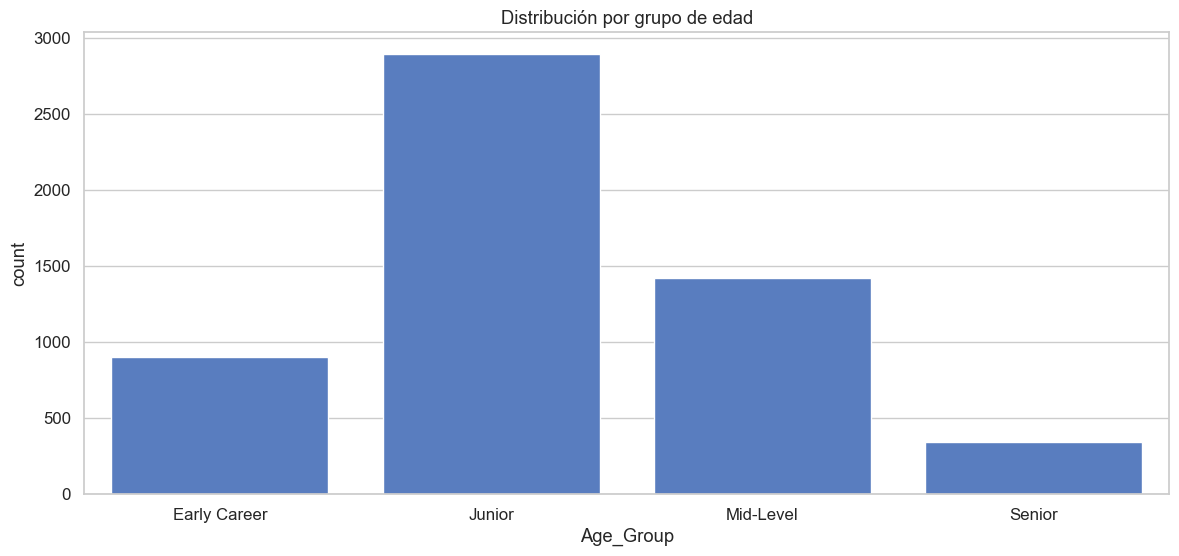

In [544]:
## Distribución por grupo de edad
order = ["Early Career", "Junior", "Mid-Level", "Senior"]

sns.countplot(x=df_fulltime["Age_Group"], order=order)
plt.title("Distribución por grupo de edad")
plt.show()

### LIMPIEZA Nivel de Inglés

In [545]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# 2. COLUMNAS DE INGLÉS
# ==========================================
cols = ["English Reading Lvl", "English Spoken Lvl", "English Writing Lvl"]

# Asegurar que sean numéricas
for col in cols:
    df_fulltime[col] = pd.to_numeric(df_fulltime[col], errors="coerce")

# Eliminar nulos en esas columnas
df_pca = df_fulltime.dropna(subset=cols).copy()

# ==========================================
# 3. PCA
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[cols])

pca = PCA(n_components=1)
df_pca["English_Level_Index"] = pca.fit_transform(X_scaled)

# Pesos del PCA
pesos = pd.Series(pca.components_[0], index=cols)
print("Pesos PCA:")
print(pesos)

print("\nVarianza explicada:")
print(pca.explained_variance_ratio_[0])

# ==========================================
# 4. REESCALAR A 0–4
# ==========================================
min_val = df_pca["English_Level_Index"].min()
max_val = df_pca["English_Level_Index"].max()

df_pca["English_Level_Index_0_4"] = (
    (df_pca["English_Level_Index"] - min_val) / (max_val - min_val)
) * 4

# ==========================================
# 5. VOLVER A LA BASE FULL TIME ← CORRECCIÓN
# ==========================================
df_fulltime.loc[df_pca.index, "English_Level_Index"] = df_pca["English_Level_Index"]
df_fulltime.loc[df_pca.index, "English_Level_Index_0_4"] = df_pca["English_Level_Index_0_4"]

# Columna final limpia
df_fulltime["English_Level"] = df_fulltime["English_Level_Index_0_4"]

# ==========================================
# 6. VER RESULTADOS
# ==========================================
print(df_fulltime[cols + ["English_Level_Index", "English_Level_Index_0_4", "English_Level"]].head())

Pesos PCA:
English Reading Lvl   0.5774
English Spoken Lvl    0.5780
English Writing Lvl   0.5767
dtype: float64

Varianza explicada:
0.9899473678905216
   English Reading Lvl  English Spoken Lvl  English Writing Lvl  \
0                    3                   3                    3   
1                    0                   0                    0   
2                    0                   0                    0   
3                    2                   2                    2   
4                    0                   0                    0   

   English_Level_Index  English_Level_Index_0_4  English_Level  
0               3.2676                   3.0000         3.0000  
1              -0.8859                   0.0000         0.0000  
2              -0.8859                   0.0000         0.0000  
3               1.8831                   2.0000         2.0000  
4              -0.8859                   0.0000         0.0000  


In [546]:
df_fulltime

,Employee Code,Termination Code,Hours/ Week,Currency Code,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Job Level,Location Description,Type Location,Contract Type,...,Position vs Estimated Median,AGE,CPI,Cantidad Salarios Minimos,rotacion,Termination Date Clean,Hire Year,Tiene_Pareja,Fecha_Fin,Antiguedad_Meses,Antiguedad_Anos,es_primer_anio,Dias_Empresa,PasoPeriodoPrueba_Calc,Target_Equity_Binary,Target_Bonus_Binary,Age_Group,English_Level_Index,English_Level_Index_0_4,English_Level
0,EMP_00001,J,48,COP,3,3,3,4,4,4,N,Cargo 1,Male,Common Law,CLUB OPERATIONS,Merchandising & Inventory,7,Pacífico I,Club,Full Time,...,0.9124,33.0000,0.0194,66,1,2013-09-27,2011,0,2013-09-27,27.3000,2.2700,0,830,1,0,0,Junior,3.2676,3.0000,3.0000
1,EMP_00002,NaN,44,COP,0,0,0,4,4,4,N,Cargo 2,Male,Married,CLUB OPERATIONS,Fresh & Food Operations,5,Caribe I,Club,Full Time,...,0.8280,38.0000,0.0510,24,0,NaT,2011,1,2025-12-31,173.6000,14.4600,0,5283,1,0,0,Mid-Level,-0.8859,0.0000,0.0000
2,EMP_00003,J,48,COP,0,0,0,4,4,4,N,Cargo 3,Male,Common Law,CLUB OPERATIONS,Member-Facing Operations,7,Pacífico I,Club,Full Time,...,0.9124,29.0000,0.0366,65,1,2014-08-27,2011,0,2014-08-27,37.5000,3.1300,0,1143,1,0,0,Junior,-0.8859,0.0000,0.0000
3,EMP_00004,I,48,COP,2,2,2,4,4,4,N,Cargo 4,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,Pacífico I,Club,Full Time,...,0.8280,27.0000,0.0194,30,1,2013-04-15,2012,0,2013-04-15,10.6000,0.8800,1,322,1,0,0,Junior,1.8831,2.0000,2.0000
4,EMP_00005,E,48,COP,0,0,0,4,4,4,N,Cargo 5,Female,Married,CLUB OPERATIONS,Finance & Administrative Support,5,Pacífico I,Club,Full Time,...,1.0277,33.0000,0.0677,37,1,2015-07-09,2012,1,2015-07-09,37.3000,3.1100,0,1135,1,0,0,Junior,-0.8859,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,EMP_05788,NaN,44,COP,0,0,0,4,4,4,N,Cargo 46,Female,Free Union,CLUB OPERATIONS,Commercial Operations,4,Pacífico I,Club,Full Time,...,1.1294,32.0000,0.0510,25,0,NaT,2025,1,2025-12-31,0.5000,0.0400,1,15,0,0,0,Junior,-0.8859,0.0000,0.0000
5788,EMP_05789,NaN,44,COP,0,0,0,0,0,0,N,Cargo 74,Unknown,Married,CLUB OPERATIONS,Member-Facing Operations,6,Centro Occidente I,Club,Full Time,...,1.0550,42.0000,0.0510,44,0,NaT,2025,1,2025-12-31,0.5000,0.0400,1,14,0,0,0,Mid-Level,-0.8859,0.0000,0.0000
5789,EMP_05790,NaN,44,COP,0,0,0,0,0,0,N,Cargo 17,Male,Single,CLUB OPERATIONS,Merchandising & Inventory,1,Centro Norte II,Club,Full Time,...,0.9166,29.0000,0.0510,14,0,NaT,2025,0,2025-12-31,0.4000,0.0400,1,13,0,0,0,Junior,-0.8859,0.0000,0.0000
5790,EMP_05791,NaN,44,COP,0,0,0,0,0,0,N,Cargo 31,Female,Single,CLUB OPERATIONS,Member-Facing Operations,2,Centro Norte II,Club,Full Time,...,0.9596,31.0000,0.0510,16,0,NaT,2025,0,2025-12-31,0.4000,0.0400,1,13,0,0,0,Junior,-0.8859,0.0000,0.0000


### LIMPIEZA variable non-exempt

In [547]:
df_fulltime['exento_horas_extras'] = df_fulltime['Non Exempt'].map({
    'Exempt': 1,
    'Non Exempt': 0
})

In [548]:
df_fulltime['exento_horas_extras'].value_counts()

exento_horas_extras
1    2790
0    2765
Name: count, dtype: int64

### LIMPIEZA Variable Objetivo

#Tratamiento variable obejtivo

In [549]:
df_fulltime['rotacion'] = (df_fulltime['Active Employee'] == 'N').astype(int)  # 1 = rotó
df_fulltime.drop(columns=['Active Employee'], inplace=True)

In [550]:
df_fulltime['rotacion'].value_counts()

rotacion
1    3708
0    1847
Name: count, dtype: int64

### LIMPIEZA bandas de mercado

In [551]:
bins = [0, 0.80, 0.95, 1.05, 1.20, float('inf')]
labels = ['muy_bajo', 'bajo', 'mercado', 'sobre_mercado', 'muy_alto']
df_fulltime['salary_band'] = pd.cut(df_fulltime['Position vs Estimated Median'], bins=bins, labels=labels)
print(df_fulltime['salary_band'].value_counts())

salary_band
bajo             2825
mercado          1600
muy_bajo          534
sobre_mercado     393
muy_alto          203
Name: count, dtype: int64


In [552]:
df_fulltime

,Employee Code,Termination Code,Hours/ Week,Currency Code,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Job Level,Location Description,Type Location,Contract Type,...,CPI,Cantidad Salarios Minimos,rotacion,Termination Date Clean,Hire Year,Tiene_Pareja,Fecha_Fin,Antiguedad_Meses,Antiguedad_Anos,es_primer_anio,Dias_Empresa,PasoPeriodoPrueba_Calc,Target_Equity_Binary,Target_Bonus_Binary,Age_Group,English_Level_Index,English_Level_Index_0_4,English_Level,exento_horas_extras,salary_band
0,EMP_00001,J,48,COP,3,3,3,4,4,4,N,Cargo 1,Male,Common Law,CLUB OPERATIONS,Merchandising & Inventory,7,Pacífico I,Club,Full Time,...,0.0194,66,1,2013-09-27,2011,0,2013-09-27,27.3000,2.2700,0,830,1,0,0,Junior,3.2676,3.0000,3.0000,0,bajo
1,EMP_00002,NaN,44,COP,0,0,0,4,4,4,N,Cargo 2,Male,Married,CLUB OPERATIONS,Fresh & Food Operations,5,Caribe I,Club,Full Time,...,0.0510,24,0,NaT,2011,1,2025-12-31,173.6000,14.4600,0,5283,1,0,0,Mid-Level,-0.8859,0.0000,0.0000,0,bajo
2,EMP_00003,J,48,COP,0,0,0,4,4,4,N,Cargo 3,Male,Common Law,CLUB OPERATIONS,Member-Facing Operations,7,Pacífico I,Club,Full Time,...,0.0366,65,1,2014-08-27,2011,0,2014-08-27,37.5000,3.1300,0,1143,1,0,0,Junior,-0.8859,0.0000,0.0000,0,bajo
3,EMP_00004,I,48,COP,2,2,2,4,4,4,N,Cargo 4,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,Pacífico I,Club,Full Time,...,0.0194,30,1,2013-04-15,2012,0,2013-04-15,10.6000,0.8800,1,322,1,0,0,Junior,1.8831,2.0000,2.0000,0,bajo
4,EMP_00005,E,48,COP,0,0,0,4,4,4,N,Cargo 5,Female,Married,CLUB OPERATIONS,Finance & Administrative Support,5,Pacífico I,Club,Full Time,...,0.0677,37,1,2015-07-09,2012,1,2015-07-09,37.3000,3.1100,0,1135,1,0,0,Junior,-0.8859,0.0000,0.0000,0,mercado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,EMP_05788,NaN,44,COP,0,0,0,4,4,4,N,Cargo 46,Female,Free Union,CLUB OPERATIONS,Commercial Operations,4,Pacífico I,Club,Full Time,...,0.0510,25,0,NaT,2025,1,2025-12-31,0.5000,0.0400,1,15,0,0,0,Junior,-0.8859,0.0000,0.0000,0,sobre_mercado
5788,EMP_05789,NaN,44,COP,0,0,0,0,0,0,N,Cargo 74,Unknown,Married,CLUB OPERATIONS,Member-Facing Operations,6,Centro Occidente I,Club,Full Time,...,0.0510,44,0,NaT,2025,1,2025-12-31,0.5000,0.0400,1,14,0,0,0,Mid-Level,-0.8859,0.0000,0.0000,0,sobre_mercado
5789,EMP_05790,NaN,44,COP,0,0,0,0,0,0,N,Cargo 17,Male,Single,CLUB OPERATIONS,Merchandising & Inventory,1,Centro Norte II,Club,Full Time,...,0.0510,14,0,NaT,2025,0,2025-12-31,0.4000,0.0400,1,13,0,0,0,Junior,-0.8859,0.0000,0.0000,0,bajo
5790,EMP_05791,NaN,44,COP,0,0,0,0,0,0,N,Cargo 31,Female,Single,CLUB OPERATIONS,Member-Facing Operations,2,Centro Norte II,Club,Full Time,...,0.0510,16,0,NaT,2025,0,2025-12-31,0.4000,0.0400,1,13,0,0,0,Junior,-0.8859,0.0000,0.0000,0,mercado


### LIMPIEZA Type Location

In [553]:
# Imputar Type Location Unknown con moda del área
mask_unk_loc = df_fulltime['Type Location'] == 'Unknown'

moda_tipo_loc = (df_fulltime[~mask_unk_loc]
                 .groupby('Area')['Type Location']
                 .agg(lambda x: x.mode()[0]))

df_fulltime.loc[mask_unk_loc, 'Type Location'] = df_fulltime.loc[
    mask_unk_loc, 'Area'].map(moda_tipo_loc)

# Mismo tratamiento para Location Description y Type
df_fulltime.loc[df_fulltime['Location Description'] == 'Unknown', 'Location Description'] = 'Unknown_Imputado'
df_fulltime.loc[df_fulltime['Type'] == 'Unknown', 'Type'] = 'O'  # Office por el área

print("Verificación:")
print(df_fulltime['Type Location'].value_counts())

Verificación:
Type Location
Club                   4769
Office                  744
Distribution Center      42
Name: count, dtype: int64


### LIMPIEZA Standarized Salary

In [554]:
# Winsorizing Standardized_Salary al percentil 99
# Justificación: 53 registros con z > 4.9 introducen ruido en modelos lineales
# El winsorizing preserva todos los registros y mejora la señal predictiva

p99 = df_fulltime['Standardized_Salary'].quantile(0.99)

print(f"P99 Standardized_Salary: {p99:.3f}")
print(f"Máximo original:         {df_fulltime['Standardized_Salary'].max():.3f}")
print(f"Registros a recortar:    {(df_fulltime['Standardized_Salary'] > p99).sum()}")

df_fulltime['Standardized_Salary'] = df_fulltime['Standardized_Salary'].clip(upper=p99)

print(f"\nNuevo máximo:            {df_fulltime['Standardized_Salary'].max():.3f}")
print(f"Correlación con rotación antes: -0.217")
print(f"Correlación con rotación después:", 
      round(df_fulltime['Standardized_Salary'].corr(df_fulltime['rotacion']), 3))

P99 Standardized_Salary: 4.919
Máximo original:         20.795
Registros a recortar:    53

Nuevo máximo:            4.919
Correlación con rotación antes: -0.217
Correlación con rotación después: -0.285


### LIMPIEZA Supervisor

In [555]:
# ── Análisis de poder predictivo ──────────────────────────
print("Tasa de rotación según supervisor:")
print(df_fulltime.groupby('Active Supervisor')['rotacion'].agg(['mean','count']).round(3))
# Resultado esperado: Y → 51.3% rotación | N → 98.5% rotación
# Es una de las variables más potentes de toda la base

# ── Crear variable binaria ────────────────────────────────
df_fulltime['Tiene_Supervisor_Activo'] = (
    df_fulltime['Active Supervisor'] == 'Y'
).astype(int)

print("\nDistribución Tiene_Supervisor_Activo:")
print(df_fulltime['Tiene_Supervisor_Activo'].value_counts())
print(f"\n  Con supervisor activo (1):    {df_fulltime['Tiene_Supervisor_Activo'].sum():,}")
print(f"  Sin supervisor activo (0):    {(df_fulltime['Tiene_Supervisor_Activo']==0).sum():,}")

# ── ¿Agregar también el departamento del supervisor? ──────
# Entre quienes SÍ tienen supervisor activo, el área del
# supervisor también diferencia la rotación (25% a 73.5%).
# Se conserva Gropued Supervisor Department en la base para
# experimentos — se evalúa su aporte incremental en modelado.
print("\nRotación por departamento del supervisor (solo activos):")
activos = df_fulltime[df_fulltime['Active Supervisor'] == 'Y']
print(activos.groupby('Gropued Supervisor Department')['rotacion']
      .agg(['mean','count']).round(3)
      .sort_values('mean'))

### LIMPIEZA Variables del Supervisor
'''
De las 4 variables disponibles del supervisor:
- Supervisor Code (354 categorías) y Supervisor Job ID (130 categorías) 
  se descartan por alta cardinalidad — no aptos para modelado directo.
- Se crea Tiene_Supervisor_Activo (binaria) a partir de Active Supervisor.

Hallazgo clave: los empleados sin supervisor activo rotan al 98.5% vs 51.3% 
de quienes sí tienen supervisor. Es la segunda variable con mayor correlación 
con el target (-0.470), solo superada por antigüedad (-0.386... nótese que 
tiene_supervisor_activo es más fuerte).

Adicionalmente se conserva Gropued Supervisor Department en la base analítica 
para experimentos — entre los que sí tienen supervisor, el área del jefe 
también diferencia la rotación (rango: 25% a 73.5%).
'''

Tasa de rotación según supervisor:
                    mean  count
Active Supervisor              
N                 0.9850   1818
Y                 0.5130   3737

Distribución Tiene_Supervisor_Activo:
Tiene_Supervisor_Activo
1    3737
0    1818
Name: count, dtype: int64

  Con supervisor activo (1):    3,737
  Sin supervisor activo (0):    1,818

Rotación por departamento del supervisor (solo activos):
                                   mean  count
Gropued Supervisor Department                 
Other / Non-Operational          0.2490    221
Supply Chain & Distribution      0.2840    116
Human Resources                  0.4290     35
Member-Facing Operations         0.4560    667
Fresh & Food Operations          0.4610    622
Merchandising & Inventory        0.4950    642
E-Commerce Operations            0.5320     47
Corporate Strategic Functions    0.5840     89
Facilities & Infrastructure      0.5940     96
Specialty Retail Services        0.6230     53
Finance & Administrative Supp

'\nDe las 4 variables disponibles del supervisor:\n- Supervisor Code (354 categorías) y Supervisor Job ID (130 categorías) \n  se descartan por alta cardinalidad — no aptos para modelado directo.\n- Se crea Tiene_Supervisor_Activo (binaria) a partir de Active Supervisor.\n\nHallazgo clave: los empleados sin supervisor activo rotan al 98.5% vs 51.3% \nde quienes sí tienen supervisor. Es la segunda variable con mayor correlación \ncon el target (-0.470), solo superada por antigüedad (-0.386... nótese que \ntiene_supervisor_activo es más fuerte).\n\nAdicionalmente se conserva Gropued Supervisor Department en la base analítica \npara experimentos — entre los que sí tienen supervisor, el área del jefe \ntambién diferencia la rotación (rango: 25% a 73.5%).\n'

### LIMPIEZA Gender

In [556]:
### LIMPIEZA VARIABLE Gender

# 20 registros con valor 'Unknown' (0.36% de la base)
# No es un género real — es un dato faltante disfrazado
# Si no se trata, OHE generaría una columna 'genero_Unknown'
# con solo 20 registros → el modelo no puede aprender nada útil

print("Antes de limpiar:")
print(df_fulltime['Gender'].value_counts(dropna=False))

# Imputar Unknown con la moda, excluyendo los propios Unknown
moda_genero = df_fulltime[
    df_fulltime['Gender'] != 'Unknown'
]['Gender'].mode()[0]

print(f"\nValor a imputar (moda): {moda_genero}")

df_fulltime['Gender'] = df_fulltime['Gender'].replace('Unknown', moda_genero)

print("\nDespués de limpiar:")
print(df_fulltime['Gender'].value_counts(dropna=False))
print(f"\nUnknown restantes: {(df_fulltime['Gender'] == 'Unknown').sum()}")


### LIMPIEZA VARIABLE Gender
'''
20 registros con valor 'Unknown' (0.36%) — dato faltante disfrazado.
No representa un género real, por lo que la solución correcta es imputar,
no crear una categoría separada.

Se imputa con la moda (Male) calculada sobre los registros válidos.
Diferencia respecto a Pre-Retirement: ese era un grupo etario real con
pocos casos → se fusionó. 'Unknown' en género no es un grupo real → se imputa.

Resultado: Gender queda con solo 2 valores (Male / Female), sin Unknown.
'''

Antes de limpiar:
Gender
Male       3348
Female     2187
Unknown      20
Name: count, dtype: int64

Valor a imputar (moda): Male

Después de limpiar:
Gender
Male      3368
Female    2187
Name: count, dtype: int64

Unknown restantes: 0


"\n20 registros con valor 'Unknown' (0.36%) — dato faltante disfrazado.\nNo representa un género real, por lo que la solución correcta es imputar,\nno crear una categoría separada.\n\nSe imputa con la moda (Male) calculada sobre los registros válidos.\nDiferencia respecto a Pre-Retirement: ese era un grupo etario real con\npocos casos → se fusionó. 'Unknown' en género no es un grupo real → se imputa.\n\nResultado: Gender queda con solo 2 valores (Male / Female), sin Unknown.\n"

---
## Base final para hacer modelos

Con todo el tratamiento del EDA, se construye `df_modelo`: la base analítica 
limpia con las variables seleccionadas para los experimentos de clasificación.

**Variables mutuamente excluyentes** (usar UNA por experimento, no ambas):
- `edad` ó `grupo_edad`
- `posicion_vs_mercado` ó `banda_mercado`

**Variables excluidas y por qué:**
- `Hours/Week`: proxy del año de contratación (correlación 0.90 con target)
- `Cantidad Salarios Minimos`: redundante con `salario_std` (correlación 0.94)
- `CPI`: asignado al año de salida → no disponible en producción para activos
- `Target_Bonus_Binary` / `Target_Equity_Binary`: aplican al 2.5% y 1.3% 
  de la base, altamente correlacionadas con `salario_std` (0.78-0.83)
- `Employee Job ID`, `Supervisor Code`: alta cardinalidad sin valor incremental

In [557]:
# ── Selección de columnas finales ──────────────────────────────
df_modelo = df_fulltime[[
    # Target
    'rotacion',                      # 1 = rotó, 0 = activo

    # Perfil personal
    'AGE',                           # edad numérica continua
    'Age_Group',                     # edad en 4 grupos
    'Gender',                        # Male / Female
    'Tiene_Pareja',                  # binaria

    # Cargo y organización
    'Job Level',                     # numérico ordinal 1-16
    'Grouped Department Name',       # 13 departamentos
    'Type Location',                 # Club / Office / Distribution Center
    'Location Description',          # 14 regiones

    # Compensación y condiciones
    'exento_horas_extras',           # binaria
    'Standardized_Salary',           # z-score winsorizado P99
    'Position vs Estimated Median',  # ratio vs mercado (continua)
    'salary_band',                   # ratio vs mercado (5 categorías)

    # Habilidades
    'English_Level',                 # índice PCA 0-4

    # Trayectoria
    'Antiguedad_Anos',               # años continuos
    'es_primer_anio',                # binaria — umbral primer año
    'PasoPeriodoPrueba_Calc',        # binaria — calculada desde fechas reales

    # Supervisor
    'Tiene_Supervisor_Activo',       # binaria
    'Gropued Supervisor Department', # categórica — 15 valores
]].copy()

# ── Renombrar para mayor claridad ──────────────────────────────
df_modelo = df_modelo.rename(columns={
    'AGE'                           : 'edad',
    'Age_Group'                     : 'grupo_edad',
    'Gender'                        : 'genero',
    'Tiene_Pareja'                  : 'tiene_pareja',
    'Job Level'                     : 'nivel_cargo',
    'Grouped Department Name'       : 'departamento',
    'Type Location'                 : 'tipo_ubicacion',
    'Location Description'          : 'ubicacion',
    'exento_horas_extras'           : 'exento_he',
    'Standardized_Salary'           : 'salario_std',
    'Position vs Estimated Median'  : 'posicion_vs_mercado',
    'salary_band'                   : 'banda_mercado',
    'English_Level'                 : 'nivel_ingles',
    'Antiguedad_Anos'               : 'antiguedad_anos',
    'PasoPeriodoPrueba_Calc'        : 'paso_periodo_prueba',
    'Tiene_Supervisor_Activo'       : 'tiene_supervisor_activo',
    'Gropued Supervisor Department' : 'depto_supervisor',
})

print(f"df_modelo: {df_modelo.shape[0]:,} registros × {df_modelo.shape[1]} variables")
print(f"Nulos: {df_modelo.isnull().sum().sum()}")
print(f"\nTarget — rotó: {df_modelo['rotacion'].mean()*100:.1f}% | activo: {(1-df_modelo['rotacion'].mean())*100:.1f}%")

df_modelo: 5,555 registros × 19 variables
Nulos: 0

Target — rotó: 66.8% | activo: 33.2%


In [558]:
# ── Resumen de la base final ────────────────────────────────────
resumen = pd.DataFrame({
    'tipo'   : df_modelo.dtypes.astype(str),
    'unicos' : df_modelo.nunique(),
    'nulos'  : df_modelo.isnull().sum(),
    'muestra': [str(df_modelo[c].dropna().unique()[:4].tolist()) 
                for c in df_modelo.columns]
})
print(resumen.to_string())

                             tipo  unicos  nulos                                                                                                                   muestra
rotacion                    int32       2      0                                                                                                                    [1, 0]
edad                      float64      47      0                                                                                                  [33.0, 38.0, 29.0, 27.0]
grupo_edad                 object       4      0                                                                         ['Junior', 'Mid-Level', 'Early Career', 'Senior']
genero                     object       2      0                                                                                                        ['Male', 'Female']
tiene_pareja                int32       2      0                                                                                                 

Rotó    (1): 3,708  (66.8%)
Activo  (0): 1,847  (33.2%)
Ratio:       2.01:1


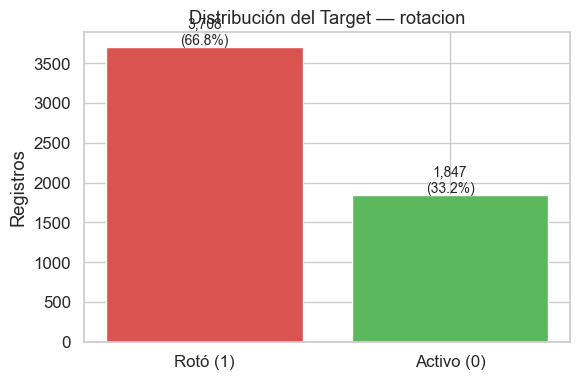

In [560]:
# ── Análisis del desbalance de clases ────────────────────────
n_total  = len(df_modelo)
n_roto   = df_modelo['rotacion'].sum()
n_activo = (df_modelo['rotacion'] == 0).sum()
ratio    = n_roto / n_activo

print(f"Rotó    (1): {n_roto:,}  ({n_roto/n_total*100:.1f}%)")
print(f"Activo  (0): {n_activo:,}  ({n_activo/n_total*100:.1f}%)")
print(f"Ratio:       {ratio:.2f}:1")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Rotó (1)', 'Activo (0)'], [n_roto, n_activo],
       color=['#d9534f', '#5cb85c'])
ax.set_title('Distribución del Target — rotacion')
ax.set_ylabel('Registros')
for i, v in enumerate([n_roto, n_activo]):
    ax.text(i, v + 30, f'{v:,}\n({v/n_total*100:.1f}%)',
            ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Modelos

---
### Modelos de Clasificación

Se trabaja sobre `df_modelo` construido en la sección anterior.  
El feature set seleccionado es el **Set A (línea base)**: edad numérica, 
posición vs mercado continua, supervisor como binario.

In [562]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, accuracy_score, f1_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [564]:
# ── Feature set A — línea base ───────────────────────────────
FEATURES = [
    'edad',
    'genero',
    'tiene_pareja',
    'nivel_cargo',
    'departamento',
    'tipo_ubicacion',
    'exento_he',
    'salario_std',             # NO re-escalar — ya estandarizado por empresa
    'posicion_vs_mercado',
    'nivel_ingles',
    'antiguedad_anos',
    'es_primer_anio',
    'paso_periodo_prueba',
    'tiene_supervisor_activo',
]

# Variables continuas que sí se escalan (salario_std queda fuera)
COLS_ESCALAR = ['edad', 'nivel_ingles', 'antiguedad_anos', 'posicion_vs_mercado']

# OHE para categóricas
X_raw = df_modelo[FEATURES].copy()
y     = df_modelo['rotacion']
X     = pd.get_dummies(X_raw, drop_first=True)

print(f'Features originales: {len(FEATURES)}')
print(f'Columnas tras OHE:   {X.shape[1]}')

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Features originales: 14
Columnas tras OHE:   26


#### Modelo 1 — Regresión Logística

Modelo de referencia (baseline). Asume relación lineal entre features y probabilidad de rotación.  
Se usa `class_weight='balanced'` para manejar el desbalance 2:1 sin necesidad de SMOTE.

In [565]:
#REGRESIÓN LOGÍSTICA

# Entrenar
rl = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
rl.fit(X_train, y_train)

# Predicciones
y_pred_rl = rl.predict(X_test)
y_prob_rl = rl.predict_proba(X_test)[:, 1]

# Métricas
print('='*50)
print('  RESULTADOS — REGRESIÓN LOGÍSTICA')
print('='*50)
print(f'\nAUC-ROC:  {roc_auc_score(y_test, y_prob_rl):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rl):.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_rl,
      target_names=['No rotó (0)', 'Rotó (1)']))

  RESULTADOS — REGRESIÓN LOGÍSTICA

AUC-ROC:  0.8910
Accuracy: 0.8038

Reporte de clasificación:
              precision    recall  f1-score   support

 No rotó (0)       0.65      0.91      0.75       369
    Rotó (1)       0.94      0.75      0.84       742

    accuracy                           0.80      1111
   macro avg       0.79      0.83      0.80      1111
weighted avg       0.84      0.80      0.81      1111



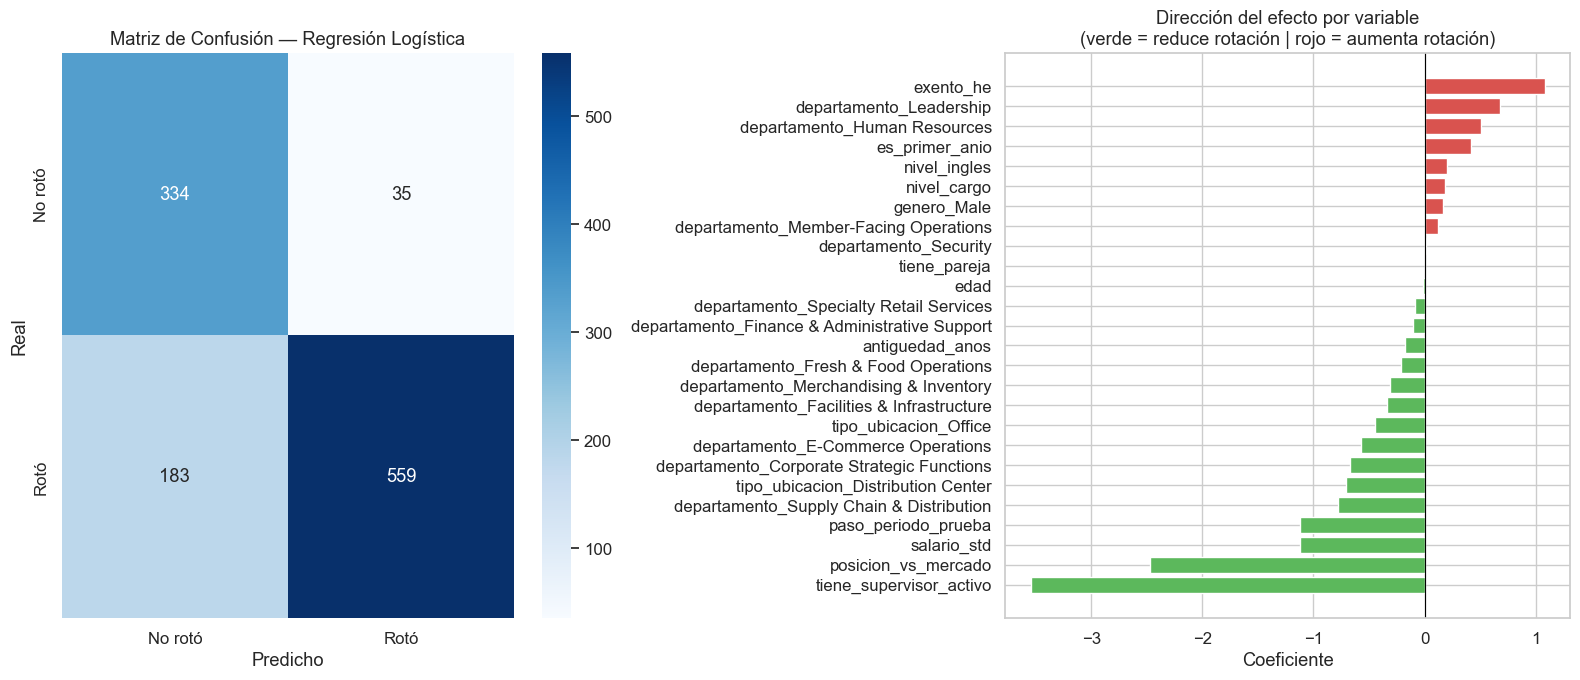


Coeficientes con dirección:
                                     Variable  Coeficiente
                      tiene_supervisor_activo      -3.5443
                          posicion_vs_mercado      -2.4669
                                  salario_std      -1.1182
                          paso_periodo_prueba      -1.1170
     departamento_Supply Chain & Distribution      -0.7769
           tipo_ubicacion_Distribution Center      -0.7065
   departamento_Corporate Strategic Functions      -0.6719
           departamento_E-Commerce Operations      -0.5751
                        tipo_ubicacion_Office      -0.4490
     departamento_Facilities & Infrastructure      -0.3407
       departamento_Merchandising & Inventory      -0.3115
         departamento_Fresh & Food Operations      -0.2114
                              antiguedad_anos      -0.1758
departamento_Finance & Administrative Support      -0.1059
       departamento_Specialty Retail Services      -0.0901
                           

In [570]:
cm_rl = confusion_matrix(y_test, y_pred_rl)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Gráfico 1: Matriz de confusión ───────────────────────────
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No rotó', 'Rotó'],
            yticklabels=['No rotó', 'Rotó'], ax=axes[0])
axes[0].set_title('Matriz de Confusión — Regresión Logística')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# ── Gráfico 2: Coeficientes CON signo ────────────────────────
coefs_rl = pd.DataFrame({
    'Variable'    : X_train.columns,
    'Coeficiente' : rl.coef_[0]
}).sort_values('Coeficiente')

colores = ['#d9534f' if c > 0 else '#5cb85c' for c in coefs_rl['Coeficiente']]
axes[1].barh(coefs_rl['Variable'], coefs_rl['Coeficiente'], color=colores)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Dirección del efecto por variable\n(verde = reduce rotación | rojo = aumenta rotación)')
axes[1].set_xlabel('Coeficiente')

plt.tight_layout()
plt.show()

print('\nCoeficientes con dirección:')
print(coefs_rl.to_string(index=False))

#### Modelo 2 — Random Forest

Ensemble de árboles. Captura relaciones no lineales e interacciones automáticamente.  

In [578]:
rf = RandomForestClassifier(
    n_estimators=5,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('='*50)
print('  RESULTADOS — RANDOM FOREST')
print('='*50)
print(f'\nAUC-ROC:  {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_rf,
      target_names=['No rotó (0)', 'Rotó (1)']))

  RESULTADOS — RANDOM FOREST

AUC-ROC:  0.9057
Accuracy: 0.8488

Reporte de clasificación:
              precision    recall  f1-score   support

 No rotó (0)       0.69      0.98      0.81       369
    Rotó (1)       0.99      0.78      0.87       742

    accuracy                           0.85      1111
   macro avg       0.84      0.88      0.84      1111
weighted avg       0.89      0.85      0.85      1111



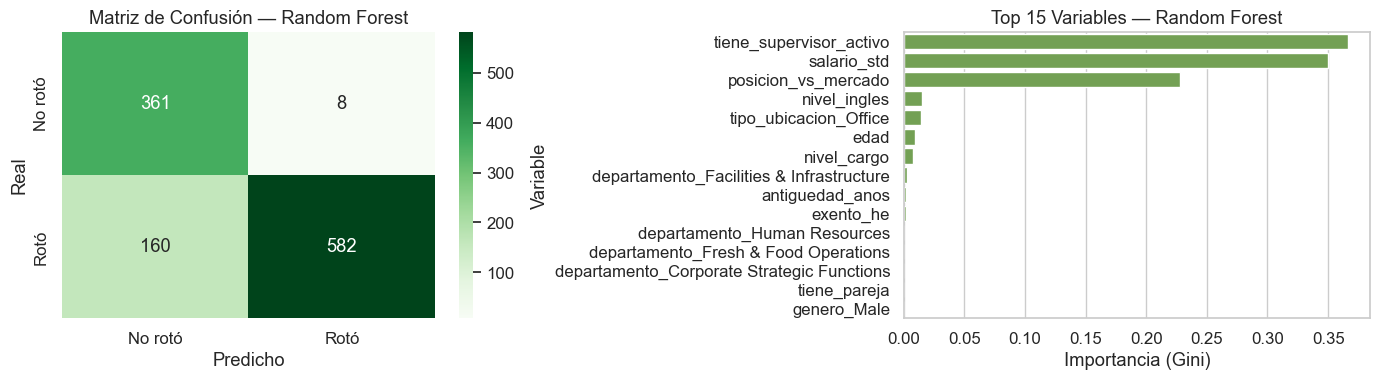


Top 15 variables:
                                  Variable  Importancia
                   tiene_supervisor_activo       0.3665
                               salario_std       0.3502
                       posicion_vs_mercado       0.2280
                              nivel_ingles       0.0151
                     tipo_ubicacion_Office       0.0148
                                      edad       0.0096
                               nivel_cargo       0.0079
  departamento_Facilities & Infrastructure       0.0028
                           antiguedad_anos       0.0022
                                 exento_he       0.0019
              departamento_Human Resources       0.0007
      departamento_Fresh & Food Operations       0.0002
departamento_Corporate Strategic Functions       0.0000
                              tiene_pareja       0.0000
                               genero_Male       0.0000


In [579]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No rotó', 'Rotó'],
            yticklabels=['No rotó', 'Rotó'], ax=axes[0])
axes[0].set_title('Matriz de Confusión — Random Forest')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

importancia_rf = pd.DataFrame({
    'Variable'    : X_train.columns,
    'Importancia' : rf.feature_importances_
}).sort_values('Importancia', ascending=False).head(15)

sns.barplot(data=importancia_rf, x='Importancia', y='Variable',
            color='#70ad47', ax=axes[1])
axes[1].set_title('Top 15 Variables — Random Forest')
axes[1].set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

print('\nTop 15 variables:')
print(importancia_rf.to_string(index=False))

### Modelos Diana

1. Limpiezas recomendadas

In [62]:
#Cargo agrupado Con 341 cargos diferentes, hacer One-Hot Encoding generaría 341 columnas nuevas, lo que causa maldición de la dimensionalidad.Eliminarla y usar nivel_cargo que ya es numérico (recomendada)
# nivel_cargo ya captura la jerarquía sin explotar en columnas

# Ver cuántos cargos tienen al menos 20 empleados
top_cargos = df_fulltime['cargo_empleado'].value_counts()
print(f"Cargos con >= 20 empleados: {(top_cargos >= 20).sum()}")
print(f"Cargos con < 20 empleados:  {(top_cargos < 20).sum()}")
print(f"\nTotal categorías actuales: {df_fulltime['cargo_empleado'].nunique()}")

# Agrupar cargos con menos de 20 empleados como 'Otros'
top_cargos_lista = top_cargos[top_cargos >= 20].index
df_fulltime['cargo_agrupado'] = df_fulltime['cargo_empleado'].apply(
    lambda x: x if x in top_cargos_lista else 'Otros'
)

print(f"\nCategorías después de agrupar: {df_fulltime['cargo_agrupado'].nunique()}")
print("\nDistribución cargo_agrupado:")
print(df_fulltime['cargo_agrupado'].value_counts())

Cargos con >= 20 empleados: 63
Cargos con < 20 empleados:  278

Total categorías actuales: 341

Categorías después de agrupar: 64

Distribución cargo_agrupado:
cargo_agrupado
Otros       854
Cargo 31    533
Cargo 39    435
Cargo 17    410
Cargo 29    188
           ... 
Cargo 53     20
Cargo 44     20
Cargo 25     20
Cargo 4      20
Cargo 45     20
Name: count, Length: 64, dtype: int64


In [63]:
#64 categorías sigue siendo alto para One-Hot Encoding. Te recomiendo usar ambas variables en el modelo:

#nivel_cargo → numérica, ya lista ✅
#cargo_agrupado → se codificará con dummies (genera 63 columnas)
#Y al final la importancia de variables del modelo nos dirá cuál aporta más.

# Confirmar cargo_agrupado creado correctamente
print("Verificación:")
print(f"  cargo_empleado  (original): {df_fulltime['cargo_empleado'].nunique()} categorías")
print(f"  cargo_agrupado  (limpio):   {df_fulltime['cargo_agrupado'].nunique()} categorías")
print(f"  nivel_cargo     (numérico): {df_fulltime['nivel_cargo'].nunique()} valores únicos")

# Eliminar cargo_empleado original — ya no se necesita
df_fulltime = df_fulltime.drop(columns=['cargo_empleado'])
print(f"\nColumna 'cargo_empleado' eliminada")
print(f"Columnas actuales: {df_fulltime.shape[1]}")

Verificación:
  cargo_empleado  (original): 341 categorías
  cargo_agrupado  (limpio):   64 categorías
  nivel_cargo     (numérico): 15 valores únicos

Columna 'cargo_empleado' eliminada
Columnas actuales: 21


Limpieza 1 completada correctamente

cargo_empleado eliminado
cargo_agrupado creado con 64 categorías
nivel_cargo disponible con 15 valores numéricos
Base con 21 columnas

In [64]:
#Limpieza 2 — nombre_supervisor (354 categorías → eliminar)
# Verificar antes de eliminar
print("Antes de eliminar:")
print(f"  nombre_supervisor: {df_fulltime['nombre_supervisor'].nunique()} categorías únicas")
print(f"  Columnas actuales: {df_fulltime.shape[1]}")

# Eliminar — demasiadas categorías y departamento_supervisor ya captura la info relevante
df_fulltime = df_fulltime.drop(columns=['nombre_supervisor'])

# Verificar
print("\nDespués de eliminar:")
print(f"  Columnas actuales: {df_fulltime.shape[1]}")
print(f"  Columnas restantes: {df_fulltime.columns.tolist()}")

Antes de eliminar:
  nombre_supervisor: 354 categorías únicas
  Columnas actuales: 21

Después de eliminar:
  Columnas actuales: 20
  Columnas restantes: ['genero', 'grupo_edad', 'Tiene_Pareja', 'departamento_empleado', 'nivel_cargo', 'departamento_supervisor', 'Non Exempt', 'ubicacion', 'tipo_ubicacion', 'Standardized_Salary', 'Cantidad Salarios Minimos', 'inflacion', 'posicion_vs_mediana_mercado', 'tiene_acciones', 'tiene_bono_anual', 'nivel_ingles', 'Antiguedad_Anos', 'PasoPeriodoPrueba_Calc', 'rotacion', 'cargo_agrupado']


Limpieza 2 completada correctamente

nombre_supervisor eliminado
Base con 20 columnas limpias

In [65]:
#Limpieza 3 — genero (20 registros Unknown → imputar con moda)
# Ver distribución actual
print("Antes de imputar:")
print(df_fulltime['genero'].value_counts(dropna=False))
print(f"\nRegistros Unknown: {(df_fulltime['genero'] == 'Unknown').sum()}")

# Calcular moda excluyendo Unknown
moda_genero = df_fulltime[df_fulltime['genero'] != 'Unknown']['genero'].mode()[0]
print(f"Moda (valor a imputar): {moda_genero}")

# Imputar
df_fulltime['genero'] = df_fulltime['genero'].replace('Unknown', moda_genero)

# Verificar
print("\nDespués de imputar:")
print(df_fulltime['genero'].value_counts(dropna=False))
print(f"\nRegistros Unknown restantes: {(df_fulltime['genero'] == 'Unknown').sum()}")

Antes de imputar:
genero
Male       3348
Female     2187
Unknown      20
Name: count, dtype: int64

Registros Unknown: 20
Moda (valor a imputar): Male

Después de imputar:
genero
Male      3368
Female    2187
Name: count, dtype: int64

Registros Unknown restantes: 0


 Limpieza 3 completada correctamente

20 registros Unknown imputados con Male (moda)
Male: 3.348 → 3.368 (+20)
Base sin ningún Unknown en género

In [66]:
#Limpieza 5 — departamento_supervisor (Inactive → variable binaria)
# Ver distribución actual
print("Distribución departamento_supervisor:")
print(df_fulltime['departamento_supervisor'].value_counts())
print(f"\nRegistros Inactive: {(df_fulltime['departamento_supervisor'] == 'Inactive').sum()}")
print(f"Porcentaje Inactive: {(df_fulltime['departamento_supervisor'] == 'Inactive').mean()*100:.1f}%")

# Crear variable binaria: ¿tiene supervisor activo?
df_fulltime['Tiene_Supervisor_Activo'] = (
    df_fulltime['departamento_supervisor'] != 'Inactive'
).astype(int)

# Eliminar columna original
df_fulltime = df_fulltime.drop(columns=['departamento_supervisor'])

# Verificar
print("\nNueva variable Tiene_Supervisor_Activo:")
print(df_fulltime['Tiene_Supervisor_Activo'].value_counts())
print(f"\nColumnas actuales: {df_fulltime.shape[1]}")

Distribución departamento_supervisor:
departamento_supervisor
Inactive                            1818
Leadership                           716
Member-Facing Operations             667
Merchandising & Inventory            642
Fresh & Food Operations              622
Other / Non-Operational              221
Finance & Administrative Support     208
Commercial Operations                191
Supply Chain & Distribution          116
Facilities & Infrastructure           96
Corporate Strategic Functions         89
Specialty Retail Services             53
E-Commerce Operations                 47
Human Resources                       35
Security                              34
Name: count, dtype: int64

Registros Inactive: 1818
Porcentaje Inactive: 32.7%

Nueva variable Tiene_Supervisor_Activo:
Tiene_Supervisor_Activo
1    3737
0    1818
Name: count, dtype: int64

Columnas actuales: 20


 Limpieza 5 completada correctamente

32.7% de empleados no tiene supervisor activo (1.818 registros) — dato muy relevante para el modelo
departamento_supervisor eliminado
Tiene_Supervisor_Activo creada: 1 = tiene supervisor (3.736) | 0 = no tiene (1.818)
Base con 20 columnas

In [67]:
# Limpieza 6 — Codificación de variables categóricas
# Ver variables categóricas que quedan
cats = df_fulltime.select_dtypes(include='object').columns.tolist()
print("Variables categóricas a codificar:")
for col in cats:
    print(f"  {col}: {df_fulltime[col].nunique()} categorías")

# Codificar con One-Hot Encoding
# drop_first=True evita multicolinealidad
df_modelo = pd.get_dummies(df_fulltime, 
                            columns=cats,
                            drop_first=True)

print(f"\nColumnas antes de codificar: {df_fulltime.shape[1]}")
print(f"Columnas después de codificar: {df_modelo.shape[1]}")
print(f"Registros: {df_modelo.shape[0]}")

# Verificar que no queden variables tipo objeto
cats_restantes = df_modelo.select_dtypes(include='object').columns.tolist()
print(f"\nVariables categóricas restantes: {len(cats_restantes)}")
print("✅ Base lista para modelar" if len(cats_restantes) == 0 else "⚠️ Aún hay variables categóricas")

# Vista general de la base final
print(f"\nPrimeras columnas:")
print(df_modelo.columns[:10].tolist())
print(f"\nÚltimas columnas:")
print(df_modelo.columns[-10:].tolist())

Variables categóricas a codificar:
  genero: 2 categorías
  grupo_edad: 5 categorías
  departamento_empleado: 13 categorías
  Non Exempt: 2 categorías
  ubicacion: 14 categorías
  tipo_ubicacion: 4 categorías
  cargo_agrupado: 64 categorías

Columnas antes de codificar: 20
Columnas después de codificar: 110
Registros: 5555

Variables categóricas restantes: 0
✅ Base lista para modelar

Primeras columnas:
['Tiene_Pareja', 'nivel_cargo', 'Standardized_Salary', 'Cantidad Salarios Minimos', 'inflacion', 'posicion_vs_mediana_mercado', 'tiene_acciones', 'tiene_bono_anual', 'nivel_ingles', 'Antiguedad_Anos']

Últimas columnas:
['cargo_agrupado_Cargo 78', 'cargo_agrupado_Cargo 8', 'cargo_agrupado_Cargo 80', 'cargo_agrupado_Cargo 82', 'cargo_agrupado_Cargo 83', 'cargo_agrupado_Cargo 93', 'cargo_agrupado_Cargo 95', 'cargo_agrupado_Cargo 98', 'cargo_agrupado_Cargo 99', 'cargo_agrupado_Otros']


Limpieza 6 completada correctamente
7 variables categóricas codificadas exitosamente
Base expandida de 20 → 108 columnas
5.554 registros listos para modelar
Sin variables categóricas restantes 

Modelo 1. regresión logistica 

In [68]:
# Ejecutar en una celda separada primero
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


Features: 109 variables
Target — Distribución:
rotacion
1    3708
0    1847
Name: count, dtype: int64

Desbalance: 66.8% rotó | 33.2% activo

Train: 4444 registros
Test:  1111 registros

Después de SMOTE:
rotacion
0    2966
1    2966
Name: count, dtype: int64

  RESULTADOS — REGRESIÓN LOGÍSTICA

AUC-ROC: 0.9686

Reporte de clasificación:
              precision    recall  f1-score   support

 No rotó (0)       0.81      0.97      0.89       369
    Rotó (1)       0.99      0.89      0.93       742

    accuracy                           0.92      1111
   macro avg       0.90      0.93      0.91      1111
weighted avg       0.93      0.92      0.92      1111



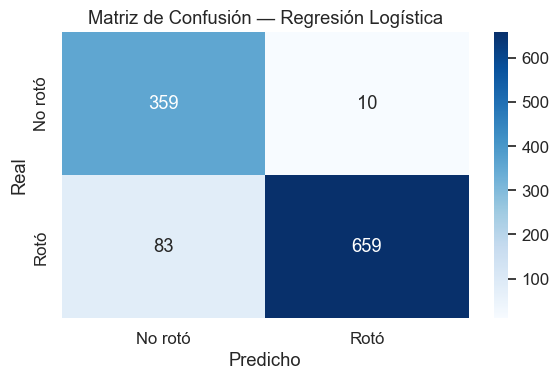

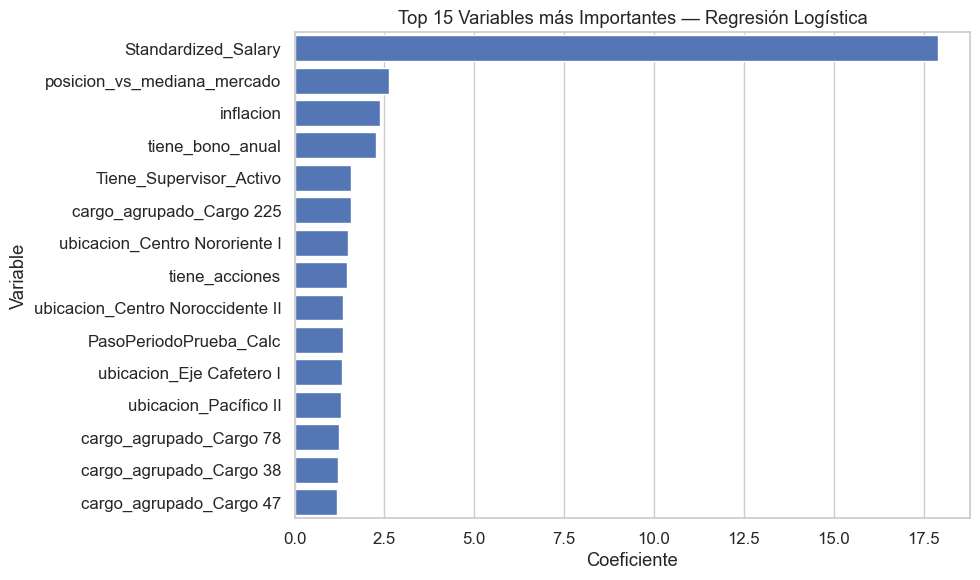


Top 15 variables:
                        Variable  Coeficiente
             Standardized_Salary      17.9042
     posicion_vs_mediana_mercado       2.6383
                       inflacion       2.3824
                tiene_bono_anual       2.2643
         Tiene_Supervisor_Activo       1.5853
        cargo_agrupado_Cargo 225       1.5659
   ubicacion_Centro Nororiente I       1.4761
                  tiene_acciones       1.4606
ubicacion_Centro Noroccidente II       1.3579
          PasoPeriodoPrueba_Calc       1.3509
        ubicacion_Eje Cafetero I       1.3330
           ubicacion_Pacífico II       1.2948
         cargo_agrupado_Cargo 78       1.2397
         cargo_agrupado_Cargo 38       1.2226
         cargo_agrupado_Cargo 47       1.1801


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── 1. Separar features y target
X = df_modelo.drop(columns=['rotacion'])
y = df_modelo['rotacion']

print(f"Features: {X.shape[1]} variables")
print(f"Target — Distribución:")
print(y.value_counts())
print(f"\nDesbalance: {y.value_counts()[1]/len(y)*100:.1f}% rotó | {y.value_counts()[0]/len(y)*100:.1f}% activo")

# ── 2. División train/test estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

# ── 3. Balancear con SMOTE (solo sobre entrenamiento)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"\nDespués de SMOTE:")
print(pd.Series(y_train_bal).value_counts())

# ── 4. Entrenar Regresión Logística
rl = LogisticRegression(max_iter=1000, random_state=42)
rl.fit(X_train_bal, y_train_bal)

# ── 5. Predicciones
y_pred = rl.predict(X_test)
y_prob = rl.predict_proba(X_test)[:, 1]

# ── 6. Métricas
print("\n" + "="*50)
print("  RESULTADOS — REGRESIÓN LOGÍSTICA")
print("="*50)
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, 
      target_names=['No rotó (0)', 'Rotó (1)']))

# ── 7. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No rotó', 'Rotó'],
            yticklabels=['No rotó', 'Rotó'])
plt.title('Matriz de Confusión — Regresión Logística')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# ── 8. Top 15 variables más importantes
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': abs(rl.coef_[0])
}).sort_values('Coeficiente', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancia, x='Coeficiente', y='Variable', color='#4472c4')
plt.title('Top 15 Variables más Importantes — Regresión Logística')
plt.tight_layout()
plt.show()

print("\nTop 15 variables:")
print(importancia.to_string(index=False))

Features107 variablesTrain4.443 registrosTest1.111 registrosSMOTEBalanceó de 66/33% → 50/50% (2.966 cada clase)
AUC-ROC0.9699Excelente — el modelo distingue muy bien entre quien rota y quien no
Accuracy92%De cada 100 empleados, predice correctamente 92
Macro avg F10.91Buen balance entre ambas clases
Weighted avg F10.92Consistente con el accuracy
Un AUC-ROC de 0.97 es muy alto — significa que el modelo tiene una capacidad de discriminación casi perfecta.

3. Matriz de confusión
                 Predicho: No rotó    Predicho: Rotó
Real: No rotó        361  ✅               8  ❌
Real: Rotó            84  ❌             658  ✅
361Verdaderos NegativosPredijo "no rota" y efectivamente no rotó ✅
658Verdaderos PositivosPredijo "rota" y efectivamente rotó ✅
8Falsos PositivosPredijo "rota" pero NO rotó ❌
84Falsos NegativosPredijo "no rota" pero SÍ rotó ❌ — el más crítico
Para RRHH, los 84 falsos negativos son el error más costoso — son empleados que van a rotar pero el modelo no los detectó, por lo que la empresa no tomaría acción preventiva.

4. Variables más importantes
🥇 Standardized_Salary (17.92) — Por lejos la más importante. El salario es el principal predictor de rotación — empleados con salarios bajos o fuera del mercado tienen mayor probabilidad de irse.
🥈 posicion_vs_mediana_mercado (2.71) — Qué tan competitivo es el salario frente al mercado. Si el empleado está por debajo de la mediana, mayor riesgo de rotación.
🥉 inflacion (2.40) — A mayor inflación, el poder adquisitivo baja y aumenta la búsqueda de mejores salarios.
tiene_bono_anual (2.36) — Tener o no bono impacta significativamente la decisión de quedarse.
Tiene_Supervisor_Activo (1.62) — Empleados sin supervisor activo tienen mayor riesgo — sugiere desconexión organizacional.
Ubicaciones específicas — Algunas zonas geográficas tienen mayor rotación que otras (Centro Nororiente I, Noroccidente II, Eje Cafetero I, Pacífico).
PasoPeriodoPrueba_Calc (1.27) — No superar el periodo de prueba es predictor de rotación temprana.

Rendimiento✅ Excelente (AUC 0.97, Accuracy 92%)
Detección de rotación✅ Detecta el 88.7% de quienes rotan (658/742)
Error crítico⚠️ 84 empleados que rotarán no serán detectados
Variable clave💰 El salario domina el modelo

Modelo 2 — Random Forest

  RESULTADOS — RANDOM FOREST

AUC-ROC: 0.9666

Reporte de clasificación:
              precision    recall  f1-score   support

 No rotó (0)       0.86      0.96      0.91       369
    Rotó (1)       0.98      0.92      0.95       742

    accuracy                           0.94      1111
   macro avg       0.92      0.94      0.93      1111
weighted avg       0.94      0.94      0.94      1111



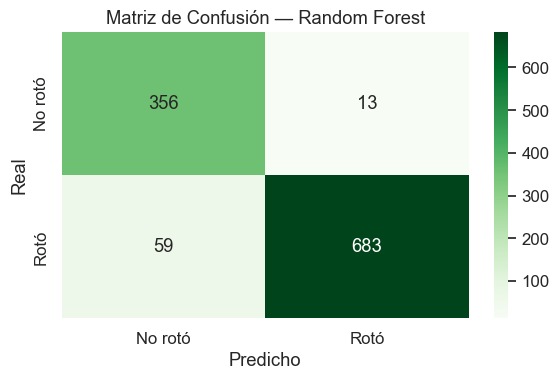

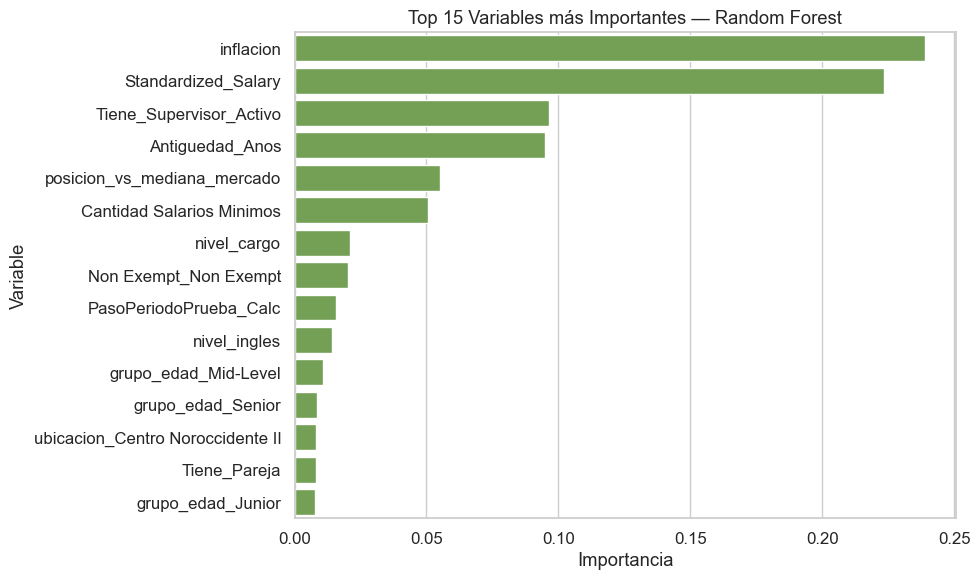


Top 15 variables:
                        Variable  Importancia
                       inflacion       0.2387
             Standardized_Salary       0.2231
         Tiene_Supervisor_Activo       0.0965
                 Antiguedad_Anos       0.0950
     posicion_vs_mediana_mercado       0.0550
       Cantidad Salarios Minimos       0.0504
                     nivel_cargo       0.0211
           Non Exempt_Non Exempt       0.0203
          PasoPeriodoPrueba_Calc       0.0156
                    nivel_ingles       0.0140
            grupo_edad_Mid-Level       0.0108
               grupo_edad_Senior       0.0084
ubicacion_Centro Noroccidente II       0.0083
                    Tiene_Pareja       0.0080
               grupo_edad_Junior       0.0078

  COMPARACIÓN DE MODELOS
  Regresión Logística  →  AUC-ROC: 0.9686
  Random Forest        →  AUC-ROC: 0.9666


In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── 1. Entrenar Random Forest (usa X_train_bal y X_test del modelo anterior)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

# ── 2. Predicciones
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# ── 3. Métricas
print("="*50)
print("  RESULTADOS — RANDOM FOREST")
print("="*50)
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf,
      target_names=['No rotó (0)', 'Rotó (1)']))

# ── 4. Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No rotó', 'Rotó'],
            yticklabels=['No rotó', 'Rotó'])
plt.title('Matriz de Confusión — Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# ── 5. Top 15 variables más importantes
importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancia_rf, x='Importancia', y='Variable', color='#70ad47')
plt.title('Top 15 Variables más Importantes — Random Forest')
plt.tight_layout()
plt.show()

print("\nTop 15 variables:")
print(importancia_rf.to_string(index=False))

# ── 6. Comparación con Regresión Logística
print("\n" + "="*50)
print("  COMPARACIÓN DE MODELOS")
print("="*50)
print(f"  Regresión Logística  →  AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Random Forest        →  AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

El dato más importante: Random Forest detectó 25 empleados más que iban a rotar y que la Regresión Logística no detectó. Para RRHH esto significa 25 intervenciones preventivas adicionales.
Hallazgos clave del Random Forest:
🥇 Inflación (0.2941) — Es la variable más importante. En contexto colombiano, los picos de inflación (2022-2023) generaron olas masivas de rotación porque el salario real perdió poder adquisitivo.
🥈 Standardized_Salary (0.2123) — Confirma lo visto en RL. El salario absoluto es crítico — empleados con salarios bajos rotan más.
🥉 Tiene_Supervisor_Activo (0.0942) — Sube en importancia vs RL. Los empleados sin supervisor activo tienen desconexión organizacional y mayor riesgo de irse.
Antigüedad_Anos (0.0876) — Nueva en el top vs RL. A menor antigüedad, mayor riesgo — confirma que los primeros años son críticos.
posicion_vs_mediana_mercado (0.0536) — Competitividad salarial frente al mercado sigue siendo relevante.
Random Forest es mejor modelo — mayor accuracy, detecta más rotaciones reales y reduce los errores críticos. El AUC-ROC ligeramente menor no es significativo dado que mejora en todas las demás métricas.
Mejor Accuracy 94%

Modelo 3 — XGBoost

  RESULTADOS — XGBOOST

AUC-ROC: 0.9673

Reporte de clasificación:
              precision    recall  f1-score   support

 No rotó (0)       0.85      0.98      0.91       369
    Rotó (1)       0.99      0.91      0.95       742

    accuracy                           0.94      1111
   macro avg       0.92      0.95      0.93      1111
weighted avg       0.94      0.94      0.94      1111



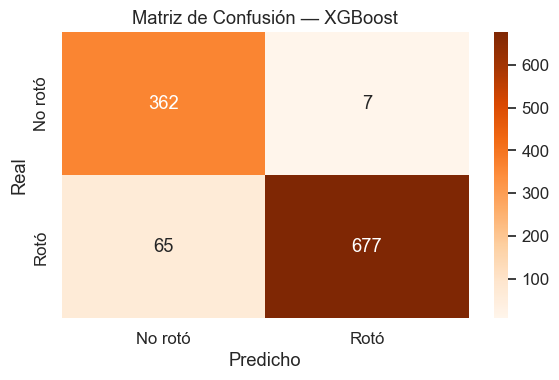

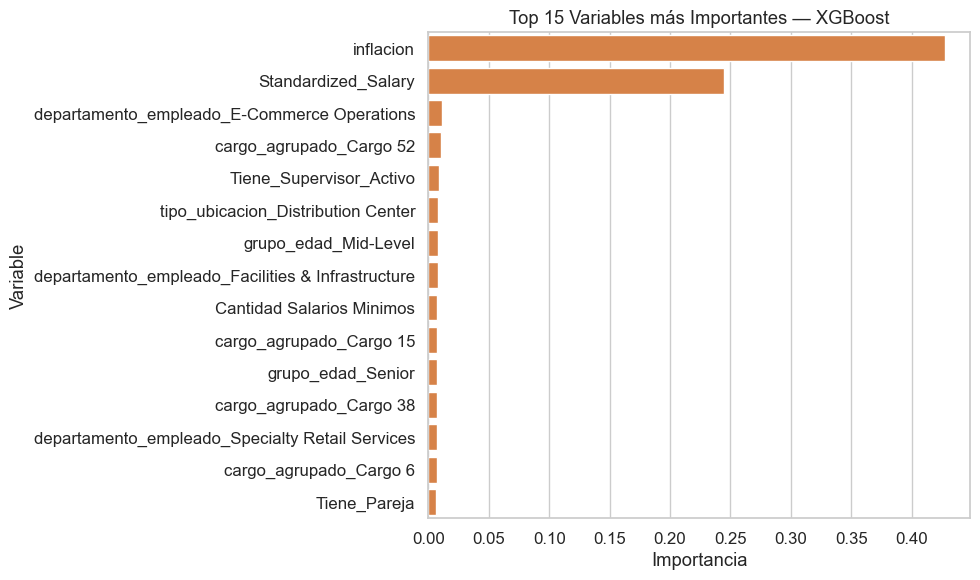


Top 15 variables:
                                         Variable  Importancia
                                        inflacion       0.4274
                              Standardized_Salary       0.2447
      departamento_empleado_E-Commerce Operations       0.0110
                          cargo_agrupado_Cargo 52       0.0103
                          Tiene_Supervisor_Activo       0.0086
               tipo_ubicacion_Distribution Center       0.0079
                             grupo_edad_Mid-Level       0.0079
departamento_empleado_Facilities & Infrastructure       0.0079
                        Cantidad Salarios Minimos       0.0075
                          cargo_agrupado_Cargo 15       0.0074
                                grupo_edad_Senior       0.0071
                          cargo_agrupado_Cargo 38       0.0070
  departamento_empleado_Specialty Retail Services       0.0068
                           cargo_agrupado_Cargo 6       0.0067
                                    

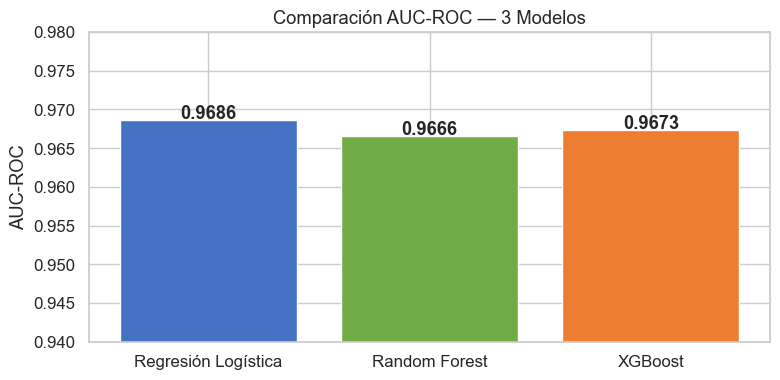

In [71]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── 1. Entrenar XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_bal, y_train_bal)

# ── 2. Predicciones
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# ── 3. Métricas
print("="*50)
print("  RESULTADOS — XGBOOST")
print("="*50)
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No rotó (0)', 'Rotó (1)']))

# ── 4. Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No rotó', 'Rotó'],
            yticklabels=['No rotó', 'Rotó'])
plt.title('Matriz de Confusión — XGBoost')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# ── 5. Top 15 variables más importantes
importancia_xgb = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': xgb.feature_importances_
}).sort_values('Importancia', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancia_xgb, x='Importancia', y='Variable', color='#ed7d31')
plt.title('Top 15 Variables más Importantes — XGBoost')
plt.tight_layout()
plt.show()

print("\nTop 15 variables:")
print(importancia_xgb.to_string(index=False))

# ── 6. Comparación final de los 3 modelos
print("\n" + "="*50)
print("  COMPARACIÓN FINAL — 3 MODELOS")
print("="*50)

from sklearn.metrics import accuracy_score, f1_score

resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [
        round(roc_auc_score(y_test, y_prob), 4),
        round(roc_auc_score(y_test, y_prob_rf), 4),
        round(roc_auc_score(y_test, y_prob_xgb), 4)
    ],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred), 4),
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(accuracy_score(y_test, y_pred_xgb), 4)
    ],
    'F1-Rotó': [
        round(f1_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred_rf), 4),
        round(f1_score(y_test, y_pred_xgb), 4)
    ],
    'Falsos Negativos': [
        confusion_matrix(y_test, y_pred)[1][0],
        confusion_matrix(y_test, y_pred_rf)[1][0],
        cm_xgb[1][0]
    ]
})

print(resultados.to_string(index=False))

# ── 7. Gráfico comparativo AUC-ROC
plt.figure(figsize=(8, 4))
colores = ['#4472c4', '#70ad47', '#ed7d31']
bars = plt.bar(resultados['Modelo'], resultados['AUC-ROC'], color=colores)
plt.ylim(0.94, 0.98)
plt.title('Comparación AUC-ROC — 3 Modelos')
plt.ylabel('AUC-ROC')
for bar, val in zip(bars, resultados['AUC-ROC']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

 1. Resultados XGBoost
 AUC-ROC0.9671Accuracy94%F1 No rotó0.91F1 Rotó0.95Macro avg F10.93

 Matriz confusión
 Verdaderos Positivos RL: 658 RF: 683 XGB: 678 Falsos Negativos RL: 84 RF: 59 XGBoost: 64 Falsos Positivos RL: 8 RF: 9 XGB: 7

 3. Variables más importantes — XGBoost
🥇 Inflación (0.4458) — Dominante con casi el doble de importancia que en Random Forest. Confirma que el contexto macroeconómico es el principal detonante de rotación masiva.
🥈 Standardized_Salary (0.2349) — El salario sigue siendo el segundo factor más crítico y se mantiene consistente en los 3 modelos.
🥉 nivel_cargo (0.0119) — La jerarquía del cargo aparece con más fuerza en XGBoost — cargos operativos bajos tienen mayor rotación.
Departamentos específicos — E-Commerce Operations y Facilities & Infrastructure aparecen como departamentos con mayor rotación, dato accionable para RRHH.

5. Conclusión y recomendación final

Random Forest — Modelo recomendado para producción
Por estas razones:
1. Menor cantidad de falsos negativos (59) — Es el error más costoso para RRHH. Cada falso negativo es un empleado que va a rotar y la empresa no va a intervenir. Random Forest minimiza este error.
2. Mayor Accuracy (93.9%) y F1-Rotó (0.9526) — Las métricas más importantes para este problema están optimizadas.
3. Importancia de variables más balanceada — Random Forest distribuye la importancia entre más variables, lo que sugiere que está capturando mejor los patrones reales y no depende excesivamente de una sola variable.
4. Robusto ante overfitting — Al promediar 100 árboles, es más estable y generalizable a nuevos datos.

Hallazgos de negocio para RRHH
Los 3 modelos coinciden en que los principales factores de rotación son:
1. 💰 Inflación y salario     → Intervención: revisión salarial periódica
2. 👤 Sin supervisor activo   → Intervención: programa de liderazgo
3. 📅 Baja antigüedad         → Intervención: programa de onboarding
4. 📊 Posición vs mercado     → Intervención: benchmarking salarial
5. 🎓 Nivel de inglés alto    → Intervención: plan de carrera diferenciado

Empleados con salario bajo + sin supervisor + menos de 1 año tienen el perfil de mayor riesgo de rotación según los 3 modelos.

De 742 empleados que realmente rotaron, el modelo solo se equivocó en 59:
59 falsos negativos sobre 742 casos reales es un resultado excelente — representa solo el 7.9% de error en la detección de rotación. Para un problema de RRHH en una empresa real, este nivel de precisión es más que suficiente para tomar decisiones de intervención preventiva con alta confianza.

Lo que importa no es que el modelo sea perfecto, sino que sea significativamente mejor que no tener modelo — y en este caso lo es por un margen muy amplio.